# Импорты

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd


from sklearn.neighbors import KNeighborsClassifier, NearestNeighbors, KNeighborsRegressor, kneighbors_graph, BallTree, KDTree
from sklearn.datasets import load_iris, make_classification, make_blobs, make_moons, make_circles, make_regression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import DistanceMetric

from collections import Counter
import heapq
from time import time

import matplotlib.pyplot as plt
#from mlxtend.plotting import plot_decision_regions

# knn в scikit-learn

In [12]:
# 1. Load dataset (Iris dataset for demonstration)
datasets = [
    # Для 3 классов лучше взять больше признаков или 2 класса
    ("make_classification (2 класса)", make_classification(
        n_samples=300, 
        n_features=2, 
        n_informative=2, 
        n_redundant=0, 
        n_classes=2,           # ← 2 класса
        random_state=42
    )),
    
    ("make_classification (3 класса, 3 признака)", make_classification(
        n_samples=300, 
        n_features=3,           # ← 3 признака для 3 классов
        n_informative=3, 
        n_redundant=0, 
        n_classes=3,
        random_state=42
    )),
    
    ("make_blobs (3 класса)", make_blobs(
        n_samples=300, 
        centers=3, 
        n_features=2, 
        random_state=42
    )),
    
    ("make_moons (2 класса)", make_moons(
        n_samples=300, 
        noise=0.1, 
        random_state=42
    )),
    
    ("make_circles (2 класса)", make_circles(
        n_samples=300, 
        noise=0.05, 
        random_state=42
    ))
]

for name, data in datasets:

    # 2. Split into training and testing sets
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

    # 3. Feature scaling (important for KNN)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # 4. Create and train the KNN classifier
    # n_neighbors = 5 is a common default, can be tuned
    knn = KNeighborsClassifier(n_neighbors=5, weights='uniform', metric='minkowski', p=2)
    knn.fit(X_train_scaled, y_train)

    # 5. Make predictions
    y_pred = knn.predict(X_test_scaled)

    # 6. Evaluate the model
    print("Name of dataset:", name)
    print(f"Accuracy: {accuracy_score(y_test, y_pred)*100}%")
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print(f"Confusion Matrix: {confusion_matrix(y_test, y_pred)}\n", )

Name of dataset: make_classification (2 класса)
Accuracy: 90.0%
Classification Report:
               precision    recall  f1-score   support

           0       0.83      1.00      0.91        30
           1       1.00      0.80      0.89        30

    accuracy                           0.90        60
   macro avg       0.92      0.90      0.90        60
weighted avg       0.92      0.90      0.90        60

Confusion Matrix: [[30  0]
 [ 6 24]]

Name of dataset: make_classification (3 класса, 3 признака)
Accuracy: 86.66666666666667%
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.80      0.84        20
           1       0.89      0.85      0.87        20
           2       0.83      0.95      0.88        20

    accuracy                           0.87        60
   macro avg       0.87      0.87      0.87        60
weighted avg       0.87      0.87      0.87        60

Confusion Matrix: [[16  1  3]
 [ 2 17  1]
 [ 0  1 19]

# Функция визуализации

# Реализация leave-one-out (кросс-валидация для гиперпараметров)

In [47]:
def loo(X,y,k,p):
    N=len(X)
    errors=0
    for i in range(N):
        X_train = np.delete(X, i, axis=0)
        y_train = np.delete(y, i, axis=0)

        X_test = X[i].reshape(1, -1)
        y_test = y[i]

        knn = KNeighborsClassifier(n_neighbors=k, weights='uniform', metric='minkowski', p=p)
        knn.fit(X_train, y_train)

        y_pred = knn.predict(X_test)[0]
        if y_pred != y_test:
            errors += 1
    return errors

# Реализация knn

In [3]:
class KNN(): 
    
    def __init__(self, k=5, metric="minkowski",p=2, dist=None, kernel = "uniform", h=1, weights_type=None, q=0.5, batch_size=None,
                 n_landmarks=100, landmarks_method='density',density_neighbors=10, avg_neighbors=5, entropy_neighbors=10):
        self.k = k
        self.metric = metric
        self.p = p
        self.q = q
        self.weights_type = weights_type
        self.kernel = kernel
        self.batch_size = batch_size
        self.dist = dist
        self.n_landmarks = n_landmarks
        self.landmarks_method = landmarks_method
        self.density_neighbors = density_neighbors
        self.avg_neighbors = avg_neighbors
        self.entropy_neighbors = entropy_neighbors
        
        if weights_type == "linear":
            linear_weights = [(self.k + 1 - i) / self.k for i in range(self.k)]
            self.weights = linear_weights
        elif weights_type == "exp":
            exp_weights = [self.q ** i for i in range(self.k)]
            self.weights = exp_weights
        elif weights_type == "parzen_fixed":
            self.h = h
            self.kernel_func = self.__get_kernel_function(kernel)
            self.weights = None  
        elif weights_type == "parzen_var":
            self.h = "Не был вызван predict" #не задаётся - будет вычисляться отдельно для каждого x
            self.kernel_func = self.__get_kernel_function(kernel)
            self.weights = None
        else:
            self.weights = [1] * self.k
        
        if batch_size is not None:
            self.batch_size = batch_size
            self.dist = None
        elif dist is None:
            self.dist = "VI"
            self.batch_size = None

    def __get_kernel_function(self, kernel):
        
        if kernel == 'rectangular':
            return lambda u: np.where(np.abs(u) <= 1, 0.5, 0)
        elif kernel == 'triangular':
            return lambda u: np.where(np.abs(u) <= 1, 1 - np.abs(u), 0)
        elif kernel == 'gaussian':
            return lambda u: np.exp(-u**2 / 2) / np.sqrt(2 * np.pi)
        elif kernel == 'epanechnikov':
            return lambda u: np.where(np.abs(u) <= 1, 0.75 * (1 - u**2), 0)
        elif kernel == 'quartic':
            return lambda u: np.where(np.abs(u) <= 1, (15/16) * (1 - u**2)**2, 0)
        else:  # uniform
            return lambda u: np.where(np.abs(u) <= 1, 1, 0)

    def __distance_approx_landmarks(self, X):
 
        n_test = len(X)
        n_train = len(self.X_train)
            
        D_xL = self.__pairwise_distances(X, self.landmarks)  # (m, c)
            
        approx_distances = D_xL @ self.D_LL_inv @ self.D_XL.T  # (m, n)
            
        return approx_distances
    
    def __pairwise_distances(self, X, Y):
        n = len(X)
        m = len(Y)
        distances = np.zeros((n, m))
        
        for i in range(n):
            diff = np.abs(X[i] - Y)
            distances[i] = np.power(np.sum(diff ** self.p, axis=1), 1/self.p)
        
        return distances
    
    def __select_landmarks_by_entropy(self, X,y):
        
        k_neighbors = self.entropy_neighbors
        nn = NearestNeighbors(n_neighbors=k_neighbors)
        nn.fit(X)
        distances, indices = nn.kneighbors(X)
        
        entropies = []
        for i in range(len(X)):
            neighbor_labels = y[indices[i]]
            label_counts = Counter(neighbor_labels)
            n = len(neighbor_labels)
            
            entropy = 0
            for count in label_counts.values():
                p = count / n
                entropy -= p * np.log2(p + 1e-8)
            entropies.append(entropy)
        
        top_indices = np.argsort(entropies)[-self.n_landmarks:]

        landmarks = []
        for idx in top_indices:
            avg_point = np.mean(X[indices[idx]], axis=0)
            landmarks.append(avg_point)
        
        return np.array(landmarks)

    def _select_landmarks_by_density(self, X):

        nn = NearestNeighbors(n_neighbors=self.density_neighbors)
        nn.fit(X)
        distances, indices = nn.kneighbors(X)

        densities = 1 / (distances.mean(axis=1) + 1e-8)
        top_indices = np.argsort(densities)[-self.n_landmarks:]
        
        landmarks = []
        for idx in top_indices:
            neighbor_avg = np.mean(X[indices[idx][:self.avg_neighbors]], axis=0)
            landmarks.append(neighbor_avg)
    
        return np.array(landmarks)
    
    def __precompute_landmarks(self, X, y):
        if self.landmarks_method == 'entropy':
            self.landmarks = self.__select_landmarks_by_entropy(X,y)
        elif self.landmarks_method == 'density':
            self.landmarks = self.__select_landmarks_by_density(X)
        else:  # random
            indices = np.random.choice(len(X), self.n_landmarks, replace=False)
            self.landmarks = X[indices]
        
        D_LL = self.__pairwise_distances(self.landmarks, self.landmarks)
        self.D_LL_inv = np.linalg.pinv(D_LL)  #псевдообратная
        
        self.D_XL = self.__pairwise_distances(X, self.landmarks)
                
    #@staticmethod
    def __distance_batch_minkowski(self, X):
        n_test = len(X)
        n_train = len(self.X_train)
        res = np.zeros((n_test, n_train))  
    
        for start in range(0, n_test, self.batch_size):
            end = min(start + self.batch_size, n_test)
            X_batch = X[start:end, :]
            
            diff = np.abs(X_batch[:, np.newaxis, :] - self.X_train[np.newaxis, :, :]) # Добавляем оси - получаем 3D
            res[start:end] = np.power(np.sum(diff ** self.p, axis=2), 1/self.p)  #Сворачиваем по axis=2 - возвращаемся к 2D
        
        return res
    
    #@staticmethod
    def __distance_matrix(self,X):
        term1 = np.sum(X**2, axis=1)[:, np.newaxis]
        term2 = np.sum(self.X_train**2, axis=1)[np.newaxis, :]
        term3 = 2 * X @ self.X_train.T
        mse = term1 + term2 - term3
        res = np.power(mse, 1/2)
        return res
        
    #@staticmethod
    def __distance_iter_vector(self, X):
        dist1=[]
        for u in X:
            mse = np.sum(u**2) + np.sum(self.X_train**2, axis=1) - 2 * u @ self.X_train.T  #np.sum(u * self.X_train, axis=1)
            dist = np.power(mse, 1/2)
            dist1.append(dist)
        res = np.vstack(dist1)
        return res

    #@staticmethod
    def __majority_vote(self,y):
        unique, counts = np.unique(y, return_counts=True)
        return unique[np.argmax(counts)]   

    def fit(self,X,y):
        self.X_train=X
        self.y_train=y

        if self.dist == 'landmarks':
            self.__precompute_landmarks(X, y)
        
        return self

    def predict(self, X):

        if not self.batch_size:
            if self.dist == "M":
                dist = self.__distance_matrix(X)
            elif self.dist == "VI":
                dist = self.__distance_iter_vector(X)
            elif self.dist == "landmarks":
                dist = self.__distance_approx_landmarks(X)
        else:
            dist = self.__distance_batch_minkowski(X)

        if self.weights_type in ["parzen_fixed", "parzen_var"]:

            if self.weights_type == "parzen_var":  #в финитных ядрах срезает сам до k
                sorted_dist=np.sort(dist, axis=1)
                h_array = sorted_dist[:, min(self.k, len(sorted_dist[0])-1)]  # массив равный длинне столбца  (тестовых), где каждый элемент 
                h_array[h_array==0] = 1e-8                                    # либо k-й элемент в строке либо len(строка)-й элемент
            else:
                h_array = np.full(len(dist[:, 0]), self.h)    # массив равный длинне столбца  (тестовых)
                
            predictions = []
            for i in range(len(dist)):
                row_dist = dist[i]
                row_labels = self.y_train
                h = h_array[i]
                u = row_dist / h
                row_weights = self.kernel_func(u)

                votes = np.bincount(row_labels, weights=row_weights)  #вместо ручной через словарь и зип
                pred = np.argmax(votes)
                predictions.append(pred)
                
        else:
            #sorted_res = np.sort(dist, axis=1)[:,:self.k]
            sorted_idx=np.argsort(dist, axis=1)[:,:self.k] #argmin
            sorted_labels_for_each_row = np.take(self.y_train, sorted_idx)     #y_train применяется для каждой строки x_test (res)
    
            predictions = []
            for i in range(len(sorted_labels_for_each_row)):
                row_labels = sorted_labels_for_each_row[i]
                row_weights = self.weights
    
                votes = np.bincount(row_labels, weights=row_weights)
                pred = np.argmax(votes)
                predictions.append(pred)
            
            #predictions = np.array(list(map(self.__majority_vote, sorted_labels_for_each_row)))

        return predictions

# Датасеты

In [4]:
datasets = [
    # Для 3 классов лучше взять больше признаков или 2 класса
    ("make_classification (2 класса)", make_classification(
        n_samples=1000, 
        n_features=10, 
        n_informative=2, 
        n_redundant=0, 
        n_classes=2,           # ← 2 класса
        random_state=42
    )),
    
    ("make_classification (3 класса, 3 признака)", make_classification(
        n_samples=1000, 
        n_features=10,           # ← 3 признака для 3 классов
        n_informative=3, 
        n_redundant=0, 
        n_classes=3,
        random_state=42
    )),
    
    ("make_blobs (3 класса)", make_blobs(
        n_samples=1000, 
        centers=3, 
        n_features=10, 
        random_state=42
    )),
    
    ("make_moons (2 класса)", make_moons(
        n_samples=1000, 
        noise=0.1, 
        random_state=42
    )),
    
    ("make_circles (2 класса)", make_circles(
        n_samples=1000, 
        noise=0.05, 
        random_state=42
    ))
]

# Запуск loo (свой и сгенерированный переменный адаптированный)

In [3]:
min_res=[np.inf, np.inf, np.inf, np.inf]
k_list=list(range(1,11))
p_list=[1,2.5,3,4,5]
print("\nOptimal parametrs")
res=[np.inf,np.inf,np.inf]
for k in k_list:
    for p in p_list:
        total_mae = 0
        
        for name, data in datasets:
            X, y = data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y
            )
            total_mae += loo(X_train, y_train, k, p)
        
        avg_mae = total_mae / len(datasets)
        print(f'k={k}, p={p}: MAE={avg_mae}')
        
        if avg_mae < res[2]:
            res[2] = avg_mae
            res[0] = k
            res[1] = p
k_opt=res[0]
p_opt=res[1]
print(f"\nЛучший k: {res[0]}, Лучший p: {res[1]}, Лучший MAE: {res[2]}")

In [6]:
k_opt=5
p_opt=1

In [60]:
def loo_knn(X_train, y_train, k, p, weights_type=None, kernel="uniform", h=1.0, q=0.5):
    """
    Leave-one-out cross validation для KNN
    Возвращает accuracy (доля правильных ответов)
    """
    n_samples = len(X_train)
    correct = 0
    
    for i in range(n_samples):
        # Оставляем i-й объект как тестовый
        X_val = X_train[i:i+1]
        y_val = y_train[i]
        
        # Остальные — обучающие
        X_loo = np.delete(X_train, i, axis=0)
        y_loo = np.delete(y_train, i, axis=0)
        
        # Создаём временный классификатор
        knn = KNN(k=k, p=p, weights_type=weights_type, kernel=kernel, h=h, q=q)
        knn.fit(X_loo, y_loo)
        
        # Предсказание
        pred = knn.predict(X_val)[0]
        
        if pred == y_val:
            correct += 1
    
    return correct / n_samples

In [62]:
# Список всех ядер
kernels = ['uniform', 'rectangular', 'triangular', 'epanechnikov', 'quartic', 'gaussian']

# Список значений h для parzen_fixed
h_values = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1, 1.25, 1.5, 1.75, 2 , 3]

# ============== LOO для Parzen Fixed с разными ядрами и h ==============
print("\n" + "="*80)
print("LOO для Parzen Fixed (разные ядра и h)")
print("="*80)

best_fixed = {'score': 0, 'kernel': None, 'h': None}

for kernel in kernels:
    for h in h_values:
        total_accuracy = 0
        
        for name, data in datasets:
            X, y = data
            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.3, random_state=42, stratify=y)
            
            # Используем loo_knn функцию (нужно определить)
            accuracy = loo_knn(X_train, y_train, k=k_opt, p=p_opt, 
                               weights_type="parzen_fixed", kernel=kernel, h=h)
            total_accuracy += accuracy
        
        avg_accuracy = total_accuracy / len(datasets)
        print(f"kernel={kernel}, h={h}: accuracy={avg_accuracy:.4f}")
        
        if avg_accuracy > best_fixed['score']:
            best_fixed['score'] = avg_accuracy
            best_fixed['kernel'] = kernel
            best_fixed['h'] = h

print(f"\nЛучший Parzen Fixed: kernel={best_fixed['kernel']}, h={best_fixed['h']}, accuracy={best_fixed['score']:.4f}")

# ============== LOO для Parzen Var с разными ядрами ==============
print("\n" + "="*80)
print("LOO для Parzen Var (разные ядра)")
print("="*80)

best_var = {'score': 0, 'kernel': None}

for kernel in kernels:
    total_accuracy = 0
    
    for name, data in datasets:
        X, y = data
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.3, random_state=42, stratify=y)
        
        accuracy = loo_knn(X_train, y_train, k=k_opt, p=p_opt,
                           weights_type="parzen_var", kernel=kernel)
        total_accuracy += accuracy
    
    avg_accuracy = total_accuracy / len(datasets)
    print(f"kernel={kernel}: accuracy={avg_accuracy:.4f}")
    
    if avg_accuracy > best_var['score']:
        best_var['score'] = avg_accuracy
        best_var['kernel'] = kernel

print(f"\nЛучший Parzen Var: kernel={best_var['kernel']}, accuracy={best_var['score']:.4f}")


LOO для Parzen Fixed (разные ядра и h)
kernel=uniform, h=0.1: accuracy=0.6246
kernel=uniform, h=0.2: accuracy=0.6243
kernel=uniform, h=0.3: accuracy=0.6123
kernel=uniform, h=0.4: accuracy=0.5914
kernel=uniform, h=0.5: accuracy=0.5706
kernel=uniform, h=0.6: accuracy=0.5546
kernel=uniform, h=0.7: accuracy=0.5377
kernel=uniform, h=0.8: accuracy=0.5214
kernel=uniform, h=0.9: accuracy=0.5109
kernel=uniform, h=1: accuracy=0.5017
kernel=uniform, h=1.25: accuracy=0.4906
kernel=uniform, h=1.5: accuracy=0.4994
kernel=uniform, h=1.75: accuracy=0.5249
kernel=uniform, h=2: accuracy=0.4763
kernel=uniform, h=3: accuracy=0.5511
kernel=rectangular, h=0.1: accuracy=0.6246
kernel=rectangular, h=0.2: accuracy=0.6243
kernel=rectangular, h=0.3: accuracy=0.6123
kernel=rectangular, h=0.4: accuracy=0.5914
kernel=rectangular, h=0.5: accuracy=0.5706
kernel=rectangular, h=0.6: accuracy=0.5546
kernel=rectangular, h=0.7: accuracy=0.5377
kernel=rectangular, h=0.8: accuracy=0.5214
kernel=rectangular, h=0.9: accuracy

# Тесты knn

## Матричный, векторно-итерационный, пакетный, библиотечный

In [63]:
classifier1 = KNN(k=k_opt, dist="M")
tm_res={}
print("\nMatrix_version")
print(f"Условия: k={classifier1.k}, metric={classifier1.metric}, dist={classifier1.dist}, p={classifier1.p}, batch_size={classifier1.batch_size}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
    start1=time()
    classifier1.fit(X_train, y_train)
    finish1=time()-start1
    start2=time()
    pred=classifier1.predict(X_test)
    finish2=time()-start2
    tm_res[name]=(finish1,finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')
s_fit=0
s_predict=0
kolvo_iter=0
for i,(j,k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit+=j
    s_predict+=k
    kolvo_iter+=1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

classifier2 = KNN(k=k_opt, dist="VI")
tm_res={}
print("\nVector-Iter version")
print(f"Условия: k={classifier2.k}, metric={classifier2.metric}, dist={classifier2.dist}, p={classifier2.p}, batch_size={classifier2.batch_size}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
    start1=time()
    classifier2.fit(X_train, y_train)
    finish1=time()-start1
    start2=time()
    pred=classifier2.predict(X_test)
    finish2=time()-start2
    tm_res[name]=(finish1,finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')
s_fit=0
s_predict=0
kolvo_iter=0
for i,(j,k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit+=j
    s_predict+=k
    kolvo_iter+=1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

classifier3 = KNN(k=k_opt, batch_size=100, p=p_opt)
tm_res={}
print("\nBatch version")
print(f"Условия: k={classifier3.k}, metric={classifier3.metric}, dist={classifier3.dist}, p={classifier3.p}, batch_size={classifier3.batch_size}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
    start1=time()
    classifier3.fit(X_train, y_train)
    finish1=time()-start1
    start2=time()
    pred=classifier3.predict(X_test)
    finish2=time()-start2
    tm_res[name]=(finish1,finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')
s_fit=0
s_predict=0
kolvo_iter=0
for i,(j,k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit+=j
    s_predict+=k
    kolvo_iter+=1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

classifier4 = KNeighborsClassifier(n_neighbors=k_opt, metric='minkowski', p=p_opt)
tm_res = {}
print("\nSklearn version")
print(f"Условия: k={classifier4.n_neighbors}, metric={classifier4.metric}, p={classifier4.p}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    
    start1 = time()
    classifier4.fit(X_train, y_train)
    finish1 = time() - start1
    
    start2 = time()
    pred = classifier4.predict(X_test)
    finish2 = time() - start2
    
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')
s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")



Matrix_version
Условия: k=5, metric=minkowski, dist=M, p=2, batch_size=None
make_classification (2 класса): 83.00
make_classification (3 класса, 3 признака): 77.33
make_blobs (3 класса): 100.00
make_moons (2 класса): 99.67
make_circles (2 класса): 96.67
make_classification (2 класса): Трейн - 3.0994415283203125e-06, Предикт - 0.03213310241699219
make_classification (3 класса, 3 признака): Трейн - 7.3909759521484375e-06, Предикт - 0.010901212692260742
make_blobs (3 класса): Трейн - 5.7220458984375e-06, Предикт - 0.009655952453613281
make_moons (2 класса): Трейн - 4.5299530029296875e-06, Предикт - 0.009012222290039062
make_circles (2 класса): Трейн - 3.337860107421875e-06, Предикт - 0.008928298950195312
Всего времени на fit: 2.4080276489257812e-05
Всего времени на predict: 0.07063078880310059
Среднее время на fit: 4.816055297851562e-06
Среднее время на predict: 0.014126157760620118

Vector-Iter version
Условия: k=5, metric=minkowski, dist=VI, p=2, batch_size=None
make_classification (2 

## Метод с опорными точками: энтропия, плотность, рандом

In [ ]:
classifier5 = KNN(k=k_opt, dist="landmarks", n_landmarks=300, landmarks_method='entropy')
tm_res = {}
print("\nLandmarks approximation version (entropy)")
print(f"Условия: k={classifier5.k}, metric={classifier5.metric}, dist={classifier5.dist}, p={classifier5.p}, n_landmarks={classifier5.n_landmarks}, landmarks_method={classifier5.landmarks_method}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    
    start1 = time()
    classifier5.fit(X_train, y_train)
    finish1 = time() - start1
    
    start2 = time()
    pred = classifier5.predict(X_test)
    finish2 = time() - start2
    
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')
s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

classifier6 = KNN(k=k_opt, dist="landmarks", n_landmarks=300, landmarks_method='destiny')
tm_res = {}
print("\nLandmarks approximation version (destiny)")
print(f"Условия: k={classifier5.k}, metric={classifier5.metric}, dist={classifier5.dist}, p={classifier5.p}, n_landmarks={classifier5.n_landmarks}, landmarks_method={classifier5.landmarks_method}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    
    start1 = time()
    classifier6.fit(X_train, y_train)
    finish1 = time() - start1
    
    start2 = time()
    pred = classifier6.predict(X_test)
    finish2 = time() - start2
    
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')
s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

classifier7 = KNN(k=k_opt, dist="landmarks", n_landmarks=300, landmarks_method='random')
tm_res = {}
print("\nLandmarks approximation version (random)")
print(f"Условия: k={classifier5.k}, metric={classifier5.metric}, dist={classifier5.dist}, p={classifier5.p}, n_landmarks={classifier5.n_landmarks}, landmarks_method={classifier5.landmarks_method}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    
    start1 = time()
    classifier7.fit(X_train, y_train)
    finish1 = time() - start1
    
    start2 = time()
    pred = classifier7.predict(X_test)
    finish2 = time() - start2
    
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')
s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

## Веса линейные, экспоненциальные, без весов  (пакетная версия)

In [45]:
# ============== 1. Batch version без весов (стандартный) ==============
classifier8 = KNN(k=k_opt, batch_size=100, p=p_opt)
tm_res = {}
print("\nBatch version (без весов)")
print(f"Условия: k={classifier8.k}, metric={classifier8.metric}, dist={classifier8.dist}, p={classifier8.p}, batch_size={classifier8.batch_size}, weights_type={classifier8.weights_type}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier8.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier8.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 2. Batch version с линейными весами ==============
classifier9 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="linear")
tm_res = {}
print("\nBatch version (линейные веса)")
print(f"Условия: k={classifier9.k}, metric={classifier9.metric}, dist={classifier9.dist}, p={classifier9.p}, batch_size={classifier9.batch_size}, weights_type={classifier9.weights_type}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier9.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier9.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 3. Batch version с экспоненциальными весами ==============
classifier10 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="exp", q=0.8475)
tm_res = {}
print("\nBatch version (экспоненциальные веса, q=0.5)")
print(f"Условия: k={classifier10.k}, metric={classifier10.metric}, dist={classifier10.dist}, p={classifier10.p}, batch_size={classifier10.batch_size}, weights_type={classifier10.weights_type}, q={classifier10.q}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier10.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier10.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")


Batch version (без весов)
Условия: k=5, metric=minkowski, dist=None, p=1, batch_size=100, weights_type=None
make_classification (2 класса): 83.00
make_classification (3 класса, 3 признака): 77.00
make_blobs (3 класса): 100.00
make_moons (2 класса): 99.67
make_circles (2 класса): 96.00
make_classification (2 класса): Трейн - 3.814697265625e-06, Предикт - 0.02548074722290039
make_classification (3 класса, 3 признака): Трейн - 6.198883056640625e-06, Предикт - 0.029822826385498047
make_blobs (3 класса): Трейн - 5.0067901611328125e-06, Предикт - 0.022734880447387695
make_moons (2 класса): Трейн - 4.76837158203125e-06, Предикт - 0.015017509460449219
make_circles (2 класса): Трейн - 5.0067901611328125e-06, Предикт - 0.01552724838256836
Всего времени на fit: 2.47955322265625e-05
Всего времени на predict: 0.10858321189880371
Среднее время на fit: 4.9591064453125e-06
Среднее время на predict: 0.02171664237976074

Batch version (линейные веса)
Условия: k=5, metric=minkowski, dist=None, p=1, batc

## Гауссово, епанечникова, треугольное, квартическое, биквадратное ядро (фикс. Парзен, пекетный)

In [54]:
# ============== 1. Parzen Fixed с ядром Gaussian ==============
classifier11 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_fixed", kernel="gaussian", h=1.0)
tm_res = {}
print("\nParzen Fixed (Gaussian kernel, h=1.0)")
print(f"Условия: k={classifier11.k}, metric={classifier11.metric}, p={classifier11.p}, batch_size={classifier11.batch_size}, weights_type={classifier11.weights_type}, kernel={classifier11.kernel}, h={classifier11.h}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier11.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier11.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 2. Parzen Fixed с ядром Epanechnikov ==============
classifier12 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_fixed", kernel="epanechnikov", h=1.0)
tm_res = {}
print("\nParzen Fixed (Epanechnikov kernel, h=1.0)")
print(f"Условия: k={classifier12.k}, metric={classifier12.metric}, p={classifier12.p}, batch_size={classifier12.batch_size}, weights_type={classifier12.weights_type}, kernel={classifier12.kernel}, h={classifier12.h}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier12.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier12.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 3. Parzen Fixed с ядром Triangular ==============
classifier13 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_fixed", kernel="triangular", h=1.0)
tm_res = {}
print("\nParzen Fixed (Triangular kernel, h=1.0)")
print(f"Условия: k={classifier13.k}, metric={classifier13.metric}, p={classifier13.p}, batch_size={classifier13.batch_size}, weights_type={classifier13.weights_type}, kernel={classifier13.kernel}, h={classifier13.h}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier13.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier13.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 4. Parzen Fixed с ядром Rectangular ==============
classifier14 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_fixed", kernel="rectangular", h=1.0)
tm_res = {}
print("\nParzen Fixed (Rectangular kernel, h=1.0)")
print(f"Условия: k={classifier14.k}, metric={classifier14.metric}, p={classifier14.p}, batch_size={classifier14.batch_size}, weights_type={classifier14.weights_type}, kernel={classifier14.kernel}, h={classifier14.h}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier14.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier14.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 5. Parzen Fixed с ядром Quartic ==============
classifier15 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_fixed", kernel="quartic", h=1.0)
tm_res = {}
print("\nParzen Fixed (Quartic kernel, h=1.0)")
print(f"Условия: k={classifier15.k}, metric={classifier15.metric}, p={classifier15.p}, batch_size={classifier15.batch_size}, weights_type={classifier15.weights_type}, kernel={classifier15.kernel}, h={classifier15.h}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier15.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier15.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")


Parzen Fixed (Gaussian kernel, h=1.0)
Условия: k=5, metric=minkowski, p=1, batch_size=100, weights_type=parzen_fixed, kernel=gaussian, h=1.0
make_classification (2 класса): 78.00
make_classification (3 класса, 3 признака): 71.33
make_blobs (3 класса): 100.00
make_moons (2 класса): 87.33
make_circles (2 класса): 50.00
make_classification (2 класса): Трейн - 6.4373016357421875e-06, Предикт - 0.03291821479797363
make_classification (3 класса, 3 признака): Трейн - 1.0013580322265625e-05, Предикт - 0.029221296310424805
make_blobs (3 класса): Трейн - 5.245208740234375e-06, Предикт - 0.026502609252929688
make_moons (2 класса): Трейн - 5.7220458984375e-06, Предикт - 0.021777629852294922
make_circles (2 класса): Трейн - 4.291534423828125e-06, Предикт - 0.016450166702270508
Всего времени на fit: 3.170967102050781e-05
Всего времени на predict: 0.12686991691589355
Среднее время на fit: 6.341934204101563e-06
Среднее время на predict: 0.02537398338317871

Parzen Fixed (Epanechnikov kernel, h=1.0)
У

## Гауссово, епанечникова, треугольное, квартическое, биквадратное ядро (перемен. Парзен, пекетный)

In [55]:
# ============== 6. Parzen Var с ядром Gaussian ==============
classifier16 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_var", kernel="gaussian")
tm_res = {}
print("\nParzen Var (Gaussian kernel, h определяется по k-му соседу)")
print(f"Условия: k={classifier16.k}, metric={classifier16.metric}, p={classifier16.p}, batch_size={classifier16.batch_size}, weights_type={classifier16.weights_type}, kernel={classifier16.kernel}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier16.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier16.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 7. Parzen Var с ядром Epanechnikov ==============
classifier17 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_var", kernel="epanechnikov")
tm_res = {}
print("\nParzen Var (Epanechnikov kernel, h определяется по k-му соседу)")
print(f"Условия: k={classifier17.k}, metric={classifier17.metric}, p={classifier17.p}, batch_size={classifier17.batch_size}, weights_type={classifier17.weights_type}, kernel={classifier17.kernel}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier17.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier17.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 8. Parzen Var с ядром Triangular ==============
classifier18 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_var", kernel="triangular")
tm_res = {}
print("\nParzen Var (Triangular kernel, h определяется по k-му соседу)")
print(f"Условия: k={classifier18.k}, metric={classifier18.metric}, p={classifier18.p}, batch_size={classifier18.batch_size}, weights_type={classifier18.weights_type}, kernel={classifier18.kernel}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier18.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier18.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 9. Parzen Var с ядром Rectangular ==============
classifier19 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_var", kernel="rectangular")
tm_res = {}
print("\nParzen Var (Rectangular kernel, h определяется по k-му соседу)")
print(f"Условия: k={classifier19.k}, metric={classifier19.metric}, p={classifier19.p}, batch_size={classifier19.batch_size}, weights_type={classifier19.weights_type}, kernel={classifier19.kernel}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier19.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier19.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 10. Parzen Var с ядром Quartic ==============
classifier20 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_var", kernel="quartic")
tm_res = {}
print("\nParzen Var (Quartic kernel, h определяется по k-му соседу)")
print(f"Условия: k={classifier20.k}, metric={classifier20.metric}, p={classifier20.p}, batch_size={classifier20.batch_size}, weights_type={classifier20.weights_type}, kernel={classifier20.kernel}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier20.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier20.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")


Parzen Var (Gaussian kernel, h определяется по k-му соседу)
Условия: k=5, metric=minkowski, p=1, batch_size=100, weights_type=parzen_var, kernel=gaussian
make_classification (2 класса): 86.67
make_classification (3 класса, 3 признака): 72.00
make_blobs (3 класса): 100.00
make_moons (2 класса): 99.67
make_circles (2 класса): 97.00
make_classification (2 класса): Трейн - 3.0994415283203125e-06, Предикт - 0.030081510543823242
make_classification (3 класса, 3 признака): Трейн - 5.245208740234375e-06, Предикт - 0.03084874153137207
make_blobs (3 класса): Трейн - 4.5299530029296875e-06, Предикт - 0.024552345275878906
make_moons (2 класса): Трейн - 4.291534423828125e-06, Предикт - 0.02321791648864746
make_circles (2 класса): Трейн - 4.76837158203125e-06, Предикт - 0.023575305938720703
Всего времени на fit: 2.193450927734375e-05
Всего времени на predict: 0.13227581977844238
Среднее время на fit: 4.38690185546875e-06
Среднее время на predict: 0.026455163955688477

Parzen Var (Epanechnikov kerne

## Прямоугольное ядро (фикс. и перемен. Парзен, пекетный)

In [16]:
# ============== 21. Parzen Fixed с ядром Uniform (k не используется, так как все объекты) ==============
classifier21 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_fixed", kernel="uniform", h=0.2)
tm_res = {}
print("\nParzen Fixed (Uniform kernel, h=)")
print(f"Условия: k={classifier21.k}, metric={classifier21.metric}, p={classifier21.p}, batch_size={classifier21.batch_size}, weights_type={classifier21.weights_type}, kernel={classifier21.kernel}, h={classifier21.h}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier21.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier21.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")

# ============== 22. Parzen Var с ядром Uniform ==============
classifier22 = KNN(k=k_opt, batch_size=100, p=p_opt, weights_type="parzen_var", kernel="uniform")
tm_res = {}
print("\nParzen Var (Uniform kernel, h определяется по k-му соседу)")
print(f"Условия: k={classifier22.k}, metric={classifier22.metric}, p={classifier22.p}, batch_size={classifier22.batch_size}, weights_type={classifier22.weights_type}, kernel={classifier22.kernel}")
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y)
    start1 = time()
    classifier22.fit(X_train, y_train)
    finish1 = time() - start1
    start2 = time()
    pred = classifier22.predict(X_test)
    finish2 = time() - start2
    tm_res[name] = (finish1, finish2)
    print(f'{name}: {accuracy_score(pred, y_test)*100:.2f}')

s_fit = 0
s_predict = 0
kolvo_iter = 0
for i, (j, k) in tm_res.items():
    print(f'{i}: Трейн - {j}, Предикт - {k}')
    s_fit += j
    s_predict += k
    kolvo_iter += 1
print(f"Всего времени на fit: {s_fit}")
print(f"Всего времени на predict: {s_predict}")
print(f"Среднее время на fit: {s_fit/kolvo_iter}")
print(f"Среднее время на predict: {s_predict/kolvo_iter}")


Parzen Fixed (Uniform kernel, h=)
Условия: k=5, metric=minkowski, p=1, batch_size=100, weights_type=parzen_fixed, kernel=uniform, h=0.2
make_classification (2 класса): 50.33
make_classification (3 класса, 3 признака): 33.33
make_blobs (3 класса): 33.33
make_moons (2 класса): 99.67
make_circles (2 класса): 96.67
make_classification (2 класса): Трейн - 4.291534423828125e-06, Предикт - 0.022472381591796875
make_classification (3 класса, 3 признака): Трейн - 5.4836273193359375e-06, Предикт - 0.026114940643310547
make_blobs (3 класса): Трейн - 3.814697265625e-06, Предикт - 0.019062519073486328
make_moons (2 класса): Трейн - 3.0994415283203125e-06, Предикт - 0.009970664978027344
make_circles (2 класса): Трейн - 1.430511474609375e-06, Предикт - 0.007683515548706055
Всего времени на fit: 1.811981201171875e-05
Всего времени на predict: 0.08530402183532715
Среднее время на fit: 3.62396240234375e-06
Среднее время на predict: 0.01706080436706543

Parzen Var (Uniform kernel, h определяется по k-му

# Эксперементы с __distance в knn

In [8]:
# №1 Векторный и итерационный подхд счёта расстояний
dist1=[]
for name, data in datasets:
    X, y = data
    X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)
    for u in X_test:
        mse = np.sum(u**2) + np.sum(X_train**2, axis=1) - 2 * u @ X_train.T  #np.sum(u * X_train, axis=1)
        dist = np.power(mse, 1/2)
        dist1.append(dist)
    res = np.vstack(dist1)
    sorted_idx=np.argsort(res, axis=1)[:,:6] #argmin
    sorted_labels_for_each_row = np.take(y_train, sorted_idx)     #y_train применяется для каждой строки res
    sorted_res = np.sort(res, axis=1)[:,:6]

    def majority_vote(labels):
        unique, counts = np.unique(labels, return_counts=True)
        return unique[np.argmax(counts)]
    predictions1 = np.array(list(map(majority_vote, sorted_labels_for_each_row)))
    break

# №2 Чисто матричный подсчет расстояний
one=np.sum(X_test**2, axis=1)[:, np.newaxis]
two=np.sum(X_train**2, axis=1)[np.newaxis, :]
mse=(one+two)
dist = mse - 2 * X_test @ X_train.T
res = np.power(dist, 1/2)

# №3 Сравнение результатов
dist1_matrix = np.vstack(dist1)  # (n_test, n_train)
print(dist1_matrix.shape)  # (n_test, n_train)
print(res.shape) 
print(f'Совпадающих элементов: {np.sum(dist1_matrix == res)}')
print(f'Не совпадающих элементов: {np.sum(dist1_matrix != res)}')
print(f'Процент совпадения матриц двух методов: {np.sum(dist1_matrix == res) / res.size * 100:.2f}%')

# №4 Предсказания для второго метода
from sklearn.metrics import accuracy_score
sorted_idx=np.argsort(res, axis=1)[:,:3] #argmin
sorted_labels_for_each_row = np.take(y_train, sorted_idx)     #y_train применяется для каждой строки res
sorted_res = np.sort(res, axis=1)[:,:3]
def majority_vote(labels):
    unique, counts = np.unique(labels, return_counts=True)
    return unique[np.argmax(counts)]
predictions2 = np.array(list(map(majority_vote, sorted_labels_for_each_row)))

# №5 Оценка предсказаний двух методов
accuracy1 = f'{accuracy_score(predictions1, y_test)*100:.2f}'
print(f'Векторный+итерационный способ: {accuracy1}%')
accuracy2 = f'{accuracy_score(predictions2, y_test)*100:.2f}'
print(f'Матричный способ: {accuracy2}%')



"""           print(X[i].reshape(1, -1).shape)
            print(X[i][np.newaxis,:].shape)"""
#axis=0 ищем среди столбца, но двигаемся по строкам сверху вниз
#axis=1 ищем среди строки, но сдвигаемся слева направо по столбцам
# в матрице x для каждого объекта вдоль столбцов мы считаем евклидово расстояния суммой разностей между строками признаков в трейн и вектором u (строкой из тестовой)

(90, 210)
(90, 210)
Совпадающих элементов: 16963
Не совпадающих элементов: 1937
Процент совпадения матриц двух методов: 89.75%
Векторный+итерационный способ: 93.33%
Матричный способ: 94.44%


'           print(X[i].reshape(1, -1).shape)\n            print(X[i][np.newaxis,:].shape)'

# KD-Tree

In [3]:
import numpy as np
import pandas as pd

class KDTree:
    
    def __init__(self, target="regression", max_depth=1000, min_samples_leaf=1, max_nodes=100000):
        self.target = target
        
        self.max_depth = max_depth
        self.min_samples_leaf = min_samples_leaf
        self.max_nodes = max_nodes
        
        self.is_leaf = np.zeros(max_nodes, dtype=bool)
        self.cd = np.zeros(max_nodes, dtype=np.int32)
        self.left = np.full(max_nodes, -1, dtype=np.int32)
        self.right = np.full(max_nodes, -1, dtype=np.int32)
        
        self.points = [None] * max_nodes
        self.responses = [None] * max_nodes
        
        self.node_count = 0
        self.tree = -1
        
        self.leaf_samples = [None] * max_nodes
        self.leaf_values = [None] * max_nodes
        
        self.n_dim = None
        self.feature_names = None
        self.global_bb = None
    
    def _add_node(self, leaf, point=None, response=None, cd=None, left=-1, right=-1,
                  leaf_samples=None, leaf_values=None):
        idx = self.node_count
        self.node_count += 1
        
        if idx >= self.max_nodes:
            raise ValueError(f"Превышен максимальный размер дерева ({self.max_nodes})")
        
        self.is_leaf[idx] = leaf
        
        if leaf:
            self.leaf_samples[idx] = leaf_samples
            self.leaf_values[idx] = leaf_values
        else:
            self.points[idx] = point
            self.responses[idx] = response
            self.cd[idx] = cd
            self.left[idx] = left
            self.right[idx] = right
        
        return idx
    
    def _build(self, X, y, depth=0):
        X = X.reset_index(drop=True)
        y = y.reset_index(drop=True)
        
        if len(X) <= self.min_samples_leaf or depth >= self.max_depth:
            return self._add_node(leaf=True, leaf_samples=X, leaf_values=y)
        
        features = X.columns  # только для датафрейма
        features_count = len(features)
        
        idx = depth % features_count
        feature_name = features[idx]
        
        column = X[feature_name]
        sorted_indices = np.argsort(column)
        
        median_pos = len(column) // 2
        median_idx = sorted_indices[median_pos]
        median_sample = X.iloc[median_idx]
        median_label = y.iloc[median_idx]
        
        left_indices = sorted_indices[:median_pos]
        right_indices = sorted_indices[median_pos + 1:]
        
        left_x = X.iloc[left_indices]
        right_x = X.iloc[right_indices]
        left_labels = y.iloc[left_indices]
        right_labels = y.iloc[right_indices]
        
        if len(left_x) == 0 or len(right_x) == 0:
            return self._add_node(leaf=True, leaf_samples=X, leaf_values=y)
        
        left_tree = self._build(left_x, left_labels, depth + 1)
        right_tree = self._build(right_x, right_labels, depth + 1)
        
        return self._add_node(
            leaf=False,
            point=median_sample,
            response=median_label,
            cd=idx,
            left=left_tree,
            right=right_tree
        )
    
    def fit(self, X, y):
        self.feature_names = X.columns
        self.n_dim = len(self.feature_names)
        
        min_coords = [X[col].min() for col in X.columns]
        max_coords = [X[col].max() for col in X.columns]
        self.global_bb = {'min': min_coords, 'max': max_coords}
        
        self.tree = self._build(X, y, depth=0)
    
    def print_tree(self, node_idx=None, depth=0):
        if node_idx is None:
            node_idx = self.tree
            if node_idx == -1:
                print("Дерево не обучено")
                return
        
        indent = "    " * depth
        
        if self.is_leaf[node_idx]:
            n_points = len(self.leaf_samples[node_idx])
            print(f"{indent}└─ 🌿 ЛИСТ: {n_points} точек")
        else:
            point = self.points[node_idx]
            print(f"{indent}├─ 🔷 УЗЕЛ: ось={self.cd[node_idx]}, ответ={self.responses[node_idx]}")
            self.print_tree(self.left[node_idx], depth + 1)
            self.print_tree(self.right[node_idx], depth + 1)
    
    def _distance(self, a, b):
        if isinstance(a, pd.Series):
            a = a.values
        if isinstance(b, pd.Series):
            b = b.values
        return np.sqrt(np.sum((a - b) ** 2))
    
    def _min_distance_to_bb(self, query, bb):
        dist_sq = 0
        for i in range(len(query)):
            if query[i] < bb['min'][i]:
                delta = bb['min'][i] - query[i]
            elif query[i] > bb['max'][i]:
                delta = query[i] - bb['max'][i]
            else:
                delta = 0
            dist_sq += delta * delta
        return np.sqrt(dist_sq)
    
    def _update_best(self, best, point, response, dist, k):
        if len(best) < k:
            best.append((point, response, dist))
            return
        
        worst_idx = 0
        worst_dist = best[0][2]
        for i in range(1, len(best)):
            if best[i][2] > worst_dist:
                worst_dist = best[i][2]
                worst_idx = i
        
        if dist < worst_dist:
            best[worst_idx] = (point, response, dist)
    
    def _get_worst_distance(self, best):
        if not best:
            return float('inf')
        return max(item[2] for item in best)
    
    def _trim_left(self, bb, cd, point):
        new_bb = {
            'min': bb['min'].copy(),
            'max': bb['max'].copy()
        }
        point_val = point.iloc[cd] if isinstance(point, pd.Series) else point[cd]
        new_bb['max'][cd] = point_val
        return new_bb
    
    def _trim_right(self, bb, cd, point):
        new_bb = {
            'min': bb['min'].copy(),
            'max': bb['max'].copy()
        }
        point_val = point.iloc[cd] if isinstance(point, pd.Series) else point[cd]
        new_bb['min'][cd] = point_val
        return new_bb
    
    def _search_nn(self, node_idx, query, best, k, bb, depth=0):
        if node_idx == -1:
            return
        
        if self.is_leaf[node_idx]:
            samples = self.leaf_samples[node_idx]
            values = self.leaf_values[node_idx]
            for i in range(len(samples)):
                point_i = samples.iloc[i]
                response_i = values.iloc[i]
                dist = self._distance(query, point_i)
                self._update_best(best, point_i, response_i, dist, k)
            return
        
        point = self.points[node_idx]
        response = self.responses[node_idx]
        dist = self._distance(query, point)
        self._update_best(best, point, response, dist, k)
        
        cd = self.cd[node_idx]
        query_val = query[cd] if not isinstance(query, pd.Series) else query[cd]
        point_val = point.iloc[cd] if isinstance(point, pd.Series) else point[cd]
        
        if query_val < point_val:
            first = self.left[node_idx]
            second = self.right[node_idx]
            bb_first = self._trim_left(bb, cd, point)
            bb_second = self._trim_right(bb, cd, point)
        else:
            first = self.right[node_idx]
            second = self.left[node_idx]
            bb_first = self._trim_right(bb, cd, point)
            bb_second = self._trim_left(bb, cd, point)
        
        self._search_nn(first, query, best, k, bb_first, depth + 1)
        
        if len(best) >= k:
            worst_dist = self._get_worst_distance(best)
            min_dist_to_bb = self._min_distance_to_bb(query, bb_second)
            if min_dist_to_bb >= worst_dist:
                return
        
        self._search_nn(second, query, best, k, bb_second, depth + 1)
    
    def predict(self, X_query, k=5):
        if self.tree == -1:
            raise ValueError("call fit at first")
        
        if self.global_bb is None:
            raise ValueError("global_bb не найден")
        
        X_query_values = X_query.values
        predictions = []
        
        for i in range(len(X_query_values)):
            query = X_query_values[i]
            best = []
            self._search_nn(self.tree, query, best, k, self.global_bb, depth=0)
            
            if len(best) > 0:
                responses = []
                for item in best:
                    resp = item[1]
                    if isinstance(resp, pd.Series):
                        resp = resp.iloc[0] if len(resp) > 0 else resp
                    responses.append(resp)
                if self.target == "regression":
                    pred = np.mean(responses)
                elif self.target == "classification":
                    from collections import Counter
                    pred = Counter(responses).most_common(1)[0][0]
                predictions.append(pred)
            else:
                predictions.append(0)
        
        return predictions

# Тесты классификации

In [15]:
import time

# ==========================================
# 1. Генерация выборки
# ==========================================
X, y = make_classification(
    n_samples=2000,          # побольше для замера скорости
    n_features=5,
    n_informative=4,
    n_redundant=1,
    n_classes=2,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(5)]
df_X = pd.DataFrame(X, columns=feature_names)
df_y = pd.Series(y, name='target')

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    df_X, df_y, test_size=0.2, random_state=42, stratify=df_y
)

print(f"Обучающая выборка: {len(X_train)}")
print(f"Тестовая выборка: {len(X_test)}")
print()

# ==========================================
# 2. Твой KDTree
# ==========================================
print("=" * 60)
print("ТВОЙ KDTree")
print("=" * 60)

start_time = time.time()
kdtree = KDTree(target = "classification",max_depth=8, min_samples_leaf=20)
kdtree.fit(X_train, y_train)
fit_time_mine = time.time() - start_time

start_time = time.time()
y_pred_mine = kdtree.predict(X_test, k=5)
predict_time_mine = time.time() - start_time

accuracy_mine = accuracy_score(y_test, y_pred_mine)

print(f"Точность: {accuracy_mine * 100:.2f}%")
print(f"Время обучения: {fit_time_mine:.4f} сек")
print(f"Время предсказания: {predict_time_mine:.4f} сек")

# ==========================================
# 3. KDTree из sklearn
# ==========================================
print("\n" + "=" * 60)
print("sklearn KNN (алгоритм 'kd_tree')")
print("=" * 60)

start_time = time.time()
sk_kdtree = KNeighborsClassifier(n_neighbors=5, algorithm='kd_tree')
sk_kdtree.fit(X_train, y_train)
fit_time_sk_kdtree = time.time() - start_time

start_time = time.time()
y_pred_sk_kdtree = sk_kdtree.predict(X_test)
predict_time_sk_kdtree = time.time() - start_time

accuracy_sk_kdtree = accuracy_score(y_test, y_pred_sk_kdtree)

print(f"Точность: {accuracy_sk_kdtree * 100:.2f}%")
print(f"Время обучения: {fit_time_sk_kdtree:.4f} сек")
print(f"Время предсказания: {predict_time_sk_kdtree:.4f} сек")

# ==========================================
# 4. KNN brute force (полный перебор)
# ==========================================
print("\n" + "=" * 60)
print("sklearn KNN (алгоритм 'brute' — полный перебор)")
print("=" * 60)

start_time = time.time()
sk_brute = KNeighborsClassifier(n_neighbors=5, algorithm='brute')
sk_brute.fit(X_train, y_train)
fit_time_sk_brute = time.time() - start_time

start_time = time.time()
y_pred_sk_brute = sk_brute.predict(X_test)
predict_time_sk_brute = time.time() - start_time

accuracy_sk_brute = accuracy_score(y_test, y_pred_sk_brute)

print(f"Точность: {accuracy_sk_brute * 100:.2f}%")
print(f"Время обучения: {fit_time_sk_brute:.4f} сек")
print(f"Время предсказания: {predict_time_sk_brute:.4f} сек")

# ==========================================
# 5. СВОДНОЕ СРАВНЕНИЕ
# ==========================================
print("\n" + "=" * 60)
print("СВОДНАЯ ТАБЛИЦА")
print("=" * 60)

print(f"{'Модель':<35} {'Точность':<12} {'Обучение':<12} {'Предсказание':<12}")
print("-" * 70)

print(f"{'Твой KDTree':<35} {accuracy_mine*100:>10.2f}%   {fit_time_mine:>8.4f}s   {predict_time_mine:>8.4f}s")
print(f"{'sklearn KDTree':<35} {accuracy_sk_kdtree*100:>10.2f}%   {fit_time_sk_kdtree:>8.4f}s   {predict_time_sk_kdtree:>8.4f}s")
print(f"{'sklearn Brute (полный перебор)':<35} {accuracy_sk_brute*100:>10.2f}%   {fit_time_sk_brute:>8.4f}s   {predict_time_sk_brute:>8.4f}s")

# ==========================================
# 6. Дополнительный анализ
# ==========================================
print("\n" + "=" * 60)
print("ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ")
print("=" * 60)

# Сравнение предсказаний твоего и sklearn KDTree
diff_mine_vs_sk = (y_pred_mine != y_pred_sk_kdtree).sum()
print(f"Твой KDTree vs sklearn KDTree: различаются в {diff_mine_vs_sk} из {len(y_test)} ({diff_mine_vs_sk/len(y_test)*100:.1f}%)")

# Сравнение предсказаний sklearn KDTree и brute
diff_sk_vs_brute = (y_pred_sk_kdtree != y_pred_sk_brute).sum()
print(f"sklearn KDTree vs Brute: различаются в {diff_sk_vs_brute} из {len(y_test)} ({diff_sk_vs_brute/len(y_test)*100:.1f}%)")

# Ускорение от kd-дерева по сравнению с полным перебором
speedup = predict_time_sk_brute / predict_time_sk_kdtree
print(f"\nsklearn KDTree быстрее brute в {speedup:.1f} раз")

# Твой KDTree vs sklearn KDTree по скорости
speedup_mine_vs_sk = predict_time_mine / predict_time_sk_kdtree
print(f"sklearn KDTree быстрее твоего в {speedup_mine_vs_sk:.1f} раз")

Обучающая выборка: 1600
Тестовая выборка: 400

ТВОЙ KDTree
Точность: 90.00%
Время обучения: 0.0912 сек
Время предсказания: 1.7670 сек

sklearn KNN (алгоритм 'kd_tree')
Точность: 90.00%
Время обучения: 0.0023 сек
Время предсказания: 0.0029 сек

sklearn KNN (алгоритм 'brute' — полный перебор)
Точность: 90.00%
Время обучения: 0.0009 сек
Время предсказания: 0.0039 сек

СВОДНАЯ ТАБЛИЦА
Модель                              Точность     Обучение     Предсказание
----------------------------------------------------------------------
Твой KDTree                              90.00%     0.0912s     1.7670s
sklearn KDTree                           90.00%     0.0023s     0.0029s
sklearn Brute (полный перебор)           90.00%     0.0009s     0.0039s

ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ
Твой KDTree vs sklearn KDTree: различаются в 0 из 400 (0.0%)
sklearn KDTree vs Brute: различаются в 0 из 400 (0.0%)

sklearn KDTree быстрее brute в 1.3 раз
sklearn KDTree быстрее твоего в 610.6 раз


# Тесты регрессии

In [38]:
import time
X, y = make_regression(n_samples=1000, n_features=5, noise=0.1, random_state=42)
X = pd.DataFrame(X, columns=[f'f{i}' for i in range(5)])
y = pd.Series(y)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# 2. Твой KDTree
# ==========================================
kdtree = KDTree(max_depth=10, min_samples_leaf=15)
kdtree.fit(X_train, y_train)

start = time.time()
y_pred_mine = kdtree.predict(X_test, k=5)
time_mine_predict = time.time() - start

# ==========================================
# 3. sklearn KDTree
# ==========================================
sk_kdtree = KNeighborsRegressor(n_neighbors=5, algorithm='kd_tree')
sk_kdtree.fit(X_train, y_train)

start = time.time()
y_pred_sk_kdtree = sk_kdtree.predict(X_test)
time_sk_kdtree_predict = time.time() - start

# ==========================================
# 4. sklearn Brute
# ==========================================
sk_brute = KNeighborsRegressor(n_neighbors=5, algorithm='brute')
sk_brute.fit(X_train, y_train)

start = time.time()
y_pred_sk_brute = sk_brute.predict(X_test)
time_sk_brute_predict = time.time() - start

# ==========================================
# 5. Сводная таблица
# ==========================================
print("\n" + "=" * 65)
print("СВОДНАЯ ТАБЛИЦА (РЕГРЕССИЯ)")
print("=" * 65)

print(f"{'Модель':<25} {'R²':<10} {'MSE':<12} {'Время предсказания':<18}")
print("-" * 65)

print(f"{'Твой KDTree':<25} {r2_score(y_test, y_pred_mine):<10.4f} {mean_squared_error(y_test, y_pred_mine):<12.4f} {time_mine_predict:<18.4f}с")
print(f"{'sklearn KDTree':<25} {r2_score(y_test, y_pred_sk_kdtree):<10.4f} {mean_squared_error(y_test, y_pred_sk_kdtree):<12.4f} {time_sk_kdtree_predict:<18.4f}с")
print(f"{'sklearn Brute':<25} {r2_score(y_test, y_pred_sk_brute):<10.4f} {mean_squared_error(y_test, y_pred_sk_brute):<12.4f} {time_sk_brute_predict:<18.4f}с")


СВОДНАЯ ТАБЛИЦА (РЕГРЕССИЯ)
Модель                    R²         MSE          Время предсказания
-----------------------------------------------------------------
Твой KDTree               0.9291     261.9600     1.0871            с
sklearn KDTree            0.9291     261.9600     0.0021            с
sklearn Brute             0.9291     261.9600     0.0025            с


# PROXIMITY GRAPH (2 fit, 2 predict)

In [2]:
import heapq
from sklearn.neighbors import kneighbors_graph

class proximity_graph():
    """
    Класс для построения графа близости (proximity graph) на основе алгоритма NSW.
    
    Граф используется для быстрого приближённого поиска ближайших соседей.
    
    Параметры
    ----------
    target : str, default="regression"
        Постановка задачи (регрессия/классификация).
    fit_start_L : int, default=10
        Количество случайных стартовых вершин при построении графа.
    cand_L : int, default=5
        Количество кандидатов, собираемых при поиске во время построения.
    closest_M : int, default=5
        Количество ближайших кандидатов, с которыми соединяется новая вершина.
    degree_M : int, default=5
        Максимальное количество соседей у любой вершины (ограничение степени).
    predict_start_L : int, default=10
        Количество случайных стартовых вершин при поиске (предсказании).
    efSearch : int, default=50
        Количество кандидатов, собираемых при поиске во время предсказания.
    k : int, default=5
        Количество ближайших соседей, возвращаемых при предсказании.
    
    Атрибуты
    ----------
    vertexes : ndarray
        Массив всех точек обучающей выборки (перемешанный).
    labels : ndarray
        Метки классов для каждой точки (перемешанные).
    graph : dict
        Словарь, где ключ — индекс вершины, значение — список индексов соседей (список смежности).
    """
    
    def __init__(self, target = "regression",fit_start_L = 10, cand_L=5, closest_M=5, degree_M=5, predict_start_L=10, efSearch=50, k=5):
        """
        Инициализация параметров графа близости.
        """
        self.target = target
        self.fit_start_L = fit_start_L
        self.predict_start_L = predict_start_L
        self.cand_L = cand_L
        self.closest_M = closest_M
        self.degree_M = degree_M
        self.k = k
        self.efSearch = efSearch
        
    def distance(self,a,b):
        """
        Вычисляет евклидово расстояние между двумя точками.
        
        Parameters
        ----------
        a, b : ndarray
            Векторы точек.
        
        Returns
        -------
        dist : float
            Евклидово расстояние.
        """
        diff = a - b
        dist = np.sqrt(np.sum((diff)**2))
        return dist

    def fit_sklearn_graph(self,X,y,n_neighbors = 10):
        """
        Построение графа близости с использованием sklearn.neighbors.kneighbors_graph.
        
        Этот метод строит KNN граф, где каждая вершина соединяется с K ближайшими соседями.
        Является альтернативой более сложному алгоритму NSW, используемому в методе fit().
        
        Параметры
        ----------
        X : pandas.DataFrame или numpy.ndarray
            Обучающие признаки (n_samples, n_features)
        y : pandas.Series или numpy.ndarray
            Целевая переменная (n_samples,)
        n_neighbors : int, default=10
            Количество ближайших соседей для каждой вершины (степень графа)
        
        Атрибуты (создаваемые методом)
        ----------
        self.vertexes : numpy.ndarray
            Массив обучающих точек (порядок соответствует индексам в графе)
        self.labels : numpy.ndarray
            Массив меток (порядок соответствует self.vertexes)
        self.graph : dict
            Словарь графа: ключ = индекс вершины, значение = список индексов соседей
        """
        if hasattr(X, 'iloc'):
            self.vertexes = X.values
            self.labels = y.values
        else:
            self.vertexes = X
            self.labels = y
        
        connectivity_matrix = kneighbors_graph(X_train,n_neighbors = n_neighbors, mode = "connectivity")
        #print(connectivity_matrix.shape)
        #print(connectivity_matrix.indptr)  #- с какой строки начинается следующая вершина (ее индекс) \ накопленная сумма ненулевых
        #print(connectivity_matrix.indices) #- список ненулевых значений
        self.graph = {}
        for i in range(connectivity_matrix.shape[0]):
            start = connectivity_matrix.indptr[i]
            end = connectivity_matrix.indptr[i + 1]
            neighbors = connectivity_matrix.indices[start:end]
            # distances = graph.data[start:end]  #для расстояния
            self.graph[i] = neighbors
        
    def fit(self,X,y):
        """
        Построение графа близости по обучающей выборке.
        
        Parameters
        ----------
        X : ndarray или DataFrame
            Обучающие признаки (n_samples, n_features).
        y : ndarray или Series
            Метки классов (n_samples,).
        
        Returns
        -------
        self : object
            Возвращает экземпляр класса.
        """
        #np.random.shuffle(X)
        np.random.seed(42) # фиксируем результаты
        indices = np.random.permutation(len(X))
        if hasattr(X, 'iloc'):
            self.vertexes = X.iloc[indices].values
            self.labels = y.iloc[indices].values
        else:
            self.vertexes = X[indices]
            self.labels = y[indices]
        
        shuffled_X = self.vertexes
        n_vertexes = len(shuffled_X)
        self.graph = {0: []}              
    
        for i in range(1, n_vertexes):
            visited = set()
            existing_indices = list(self.graph.keys())
            size=min(self.fit_start_L, len(existing_indices))
            start_points = np.random.choice(existing_indices, size=size, replace=False)
            distances = [self.distance(shuffled_X[i], shuffled_X[point]) for point in start_points]
            queue = [(dist, point) for dist, point in zip(distances, start_points)]  #point это индекс
            heapq.heapify(queue)
            candidates = []

            while queue and len(candidates) < self.cand_L:
                dist_cand, cand = heapq.heappop(queue)
    
                if cand in visited:
                    continue
                    
                visited.add(cand)
                candidates.append(cand)

                neighbours = self.graph.get(cand, [])
                for neigh in neighbours:
                    if neigh not in visited:
                        dist = self.distance(shuffled_X[neigh], shuffled_X[i])
                        heapq.heappush(queue, (dist, neigh))

            closest_candidates = candidates[:self.closest_M]
            #self.graph.setdefault(i, [])
            #self.graph[i].extend(closest_candidates)
            self.graph[i] = closest_candidates.copy()

            if len(self.graph[i]) > self.degree_M:
                neighs = self.graph[i]
                dists = [(self.distance(shuffled_X[i], shuffled_X[neigh]), neigh) for neigh in neighs]
                dists.sort(key=lambda x: x[0])
                self.graph[i] = [neigh for _, neigh in dists][:self.degree_M]
            
            for cand in closest_candidates:  #обрезаем список для сохранения ближайших соседей до каждой из вершин графа
                vertex_neigbours = self.graph[cand]
                vertex_neigbours.append(i)
                if len(vertex_neigbours) > self.degree_M:
                    distances = [(self.distance(shuffled_X[neigh], shuffled_X[cand]), neigh) for neigh in vertex_neigbours]
                    distances.sort(key = lambda x: x[0])
                    self.graph[cand] = [neigh for _,neigh in distances][:self.degree_M]

    def predict_simple(self, X):
        """
        Упрощённый метод предсказания (эвристика).

        Примечание: этот метод является эвристикой, более медлнной, чем predict().
        
        Parameters
        ----------
        X : ndarray или DataFrame
            Тестовые точки (n_samples, n_features).
        
        Returns
        -------
        predictions : ndarray
            Предсказанные классы (n_samples,).
        """
        predictions = []
        X = X.values if hasattr(X, 'iloc') else X
        for query in X:
            # Найти вершины с минимальным расстоянием до тестовой
            distances = []
            for i in range(len(self.vertexes)):
                dist = self.distance(query, self.vertexes[i])
                distances.append((dist, i))
            
            distances.sort(key=lambda x: x[0])
            
            if self.k == 1:
                nearest_indices = [distances[0][1]]
            else:
                nearest_indices = [idx for _, idx in distances[:self.k]]
            
            # Собрать всех соседей этих вершин
            neighbor_indices = set()
            for idx in nearest_indices:
                neighbor_indices.add(idx)  # включаем саму вершину
                neighbor_indices.update(self.graph.get(idx, []))

            labels = [self.labels[idx] for idx in neighbor_indices]
            
            if self.target == "classification":
                from collections import Counter
                predictions.append(Counter(labels).most_common(1)[0][0])
            elif self.target == "regression":
                predictions.append(np.mean(labels))
    
        return np.array(predictions)
    
    def predict(self, X):
        """
        Быстрый метод предсказания с использованием графа (best-first search).
        
        Parameters
        ----------
        X : ndarray или DataFrame
            Тестовые точки (n_samples, n_features).
        
        Returns
        -------
        predictions : ndarray
            Предсказанные классы (n_samples,).
        """
        X = X.values if hasattr(X, 'iloc') else X
        
        predictions = []
        
        for query in X:
            existing_indices = list(self.graph.keys())
            size = min(self.predict_start_L, len(existing_indices))
            start_points = np.random.choice(existing_indices, size=size, replace=False)
            
            queue = []
            visited = set()
            candidates = []
            
            for v in start_points:
                dist = self.distance(query, self.vertexes[v])
                heapq.heappush(queue, (dist, v))
            
            while queue and len(candidates) < self.efSearch:
                dist_v, v = heapq.heappop(queue)
                
                if v in visited:
                    continue
                
                visited.add(v)
                candidates.append((dist_v, v))
                
                for u in self.graph.get(v, []):
                    if u not in visited:
                        dist_u = self.distance(query, self.vertexes[u])
                        heapq.heappush(queue, (dist_u, u))
            
            candidates.sort(key=lambda x: x[0])
            k_nearest_indices = [idx for _, idx in candidates[:self.k]]
            
            labels = [self.labels[idx] for idx in k_nearest_indices]
            
            if self.target == "classification":
                from collections import Counter
                predictions.append(Counter(labels).most_common(1)[0][0])
            elif self.target == "regression":
                predictions.append(np.mean(labels))
        
        return np.array(predictions)

# Тесты классификации

In [128]:
from time import time
# ============== ГЕНЕРАЦИЯ ДАННЫХ ==============
X, y = make_classification(
    n_samples=2000,
    n_features=5,
    n_informative=4,
    n_redundant=1,
    n_classes=2,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(5)]
df_X = pd.DataFrame(X, columns=feature_names)
df_y = pd.Series(y, name='target')

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    df_X, df_y, test_size=0.2, random_state=42, stratify=df_y
)

# ============== ОБУЧЕНИЕ CUSTOM GRAPH ==============
print("="*50)
print("ПОСТРОЕНИЕ CUSTOM GRAPH (NSW)")
print("="*50)

pg_custom = proximity_graph(
    target="classification",
    fit_start_L=10,
    cand_L=10,
    closest_M=30,
    degree_M=30,
    predict_start_L=5,
    efSearch=200,
    k=11
)
pg_custom.fit(X_train, y_train)

# predict_simple (custom)
start = time()
y_pred1_custom = pg_custom.predict_simple(X_test)
time_simple_custom = time() - start

# predict (custom)
start = time()
y_pred2_custom = pg_custom.predict(X_test)
time_graph_custom = time() - start

# ============== ОБУЧЕНИЕ SKLEARN GRAPH (kneighbors_graph) ==============
print("\n" + "="*50)
print("ПОСТРОЕНИЕ SKLEARN GRAPH (kneighbors_graph)")
print("="*50)

pg_sklearn = proximity_graph(target="classification")
pg_sklearn.fit_sklearn_graph(X_train, y_train,n_neighbors = 15)

# predict_simple (sklearn)
start = time()
y_pred1_sklearn = pg_sklearn.predict_simple(X_test)
time_simple_sklearn = time() - start

# predict (sklearn)
start = time()
y_pred2_sklearn = pg_sklearn.predict(X_test)
time_graph_sklearn = time() - start

# ============== РЕЗУЛЬТАТЫ ==============
print("\n" + "="*60)
print("СРАВНЕНИЕ МЕТОДОВ")
print("="*60)

print("\n" + "-"*40)
print("CUSTOM GRAPH (NSW)")
print("-"*40)
print(f"Predict Simple:")
print(f"  Точность: {accuracy_score(y_pred1_custom, y_test)*100:.2f}%")
print(f"  Время: {time_simple_custom:.4f} сек")

print(f"\nPredict (граф):")
print(f"  Точность: {accuracy_score(y_pred2_custom, y_test)*100:.2f}%")
print(f"  Время: {time_graph_custom:.4f} сек")
print(f"  Ускорение: {time_simple_custom/time_graph_custom:.2f}x")

print("\n" + "-"*40)
print("SKLEARN GRAPH (kneighbors_graph)")
print("-"*40)
print(f"Predict Simple:")
print(f"  Точность: {accuracy_score(y_pred1_sklearn, y_test)*100:.2f}%")
print(f"  Время: {time_simple_sklearn:.4f} сек")

print(f"\nPredict (граф):")
print(f"  Точность: {accuracy_score(y_pred2_sklearn, y_test)*100:.2f}%")
print(f"  Время: {time_graph_sklearn:.4f} сек")
print(f"  Ускорение: {time_simple_sklearn/time_graph_sklearn:.2f}x")

# ============== СРАВНЕНИЕ ГРАФОВ ==============
print("\n" + "="*60)
print("СРАВНЕНИЕ ГРАФОВ")
print("="*60)

print(f"Custom Graph: {len(pg_custom.graph)} вершин, "
      f"средняя степень = {np.mean([len(v) for v in pg_custom.graph.values()]):.1f}")
print(f"Sklearn Graph: {len(pg_sklearn.graph)} вершин, "
      f"средняя степень = {np.mean([len(v) for v in pg_sklearn.graph.values()]):.1f}")

ПОСТРОЕНИЕ CUSTOM GRAPH (NSW)

ПОСТРОЕНИЕ SKLEARN GRAPH (kneighbors_graph)

СРАВНЕНИЕ МЕТОДОВ

----------------------------------------
CUSTOM GRAPH (NSW)
----------------------------------------
Predict Simple:
  Точность: 89.00%
  Время: 2.8569 сек

Predict (граф):
  Точность: 89.75%
  Время: 4.3890 сек
  Ускорение: 0.65x

----------------------------------------
SKLEARN GRAPH (kneighbors_graph)
----------------------------------------
Predict Simple:
  Точность: 89.75%
  Время: 2.6184 сек

Predict (граф):
  Точность: 89.50%
  Время: 1.0270 сек
  Ускорение: 2.55x

СРАВНЕНИЕ ГРАФОВ
Custom Graph: 1600 вершин, средняя степень = 18.1
Sklearn Graph: 1600 вершин, средняя степень = 15.0


# Тесты регрессии

In [11]:
from time import time
# ============== ГЕНЕРАЦИЯ ДАННЫХ ДЛЯ РЕГРЕССИИ ==============
X, y = make_regression(
    n_samples=2000,          # побольше для замера скорости
    n_features=5,
    n_informative=4,
    noise=0.1,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(5)]
df_X = pd.DataFrame(X, columns=feature_names)
df_y = pd.Series(y, name='target')

# Разделение
X_train, X_test, y_train, y_test = train_test_split(
    df_X, df_y, test_size=0.2, random_state=42
)

# ============== ОБУЧЕНИЕ CUSTOM GRAPH (NSW) ДЛЯ РЕГРЕССИИ ==============
print("="*50)
print("ПОСТРОЕНИЕ CUSTOM GRAPH (NSW) - РЕГРЕССИЯ")
print("="*50)

pg_custom = proximity_graph(
    target="regression",
    fit_start_L=10,
    cand_L=10,
    closest_M=30,
    degree_M=30,
    predict_start_L=5,
    efSearch=200,
    k=11
)
pg_custom.fit(X_train, y_train)

# predict_simple (custom)
start = time()
y_pred1_custom = pg_custom.predict_simple(X_test)
time_simple_custom = time() - start

# predict (custom)
start = time()
y_pred2_custom = pg_custom.predict(X_test)
time_graph_custom = time() - start

# ============== ОБУЧЕНИЕ SKLEARN GRAPH (kneighbors_graph) ДЛЯ РЕГРЕССИИ ==============
print("\n" + "="*50)
print("ПОСТРОЕНИЕ SKLEARN GRAPH (kneighbors_graph) - РЕГРЕССИЯ")
print("="*50)

pg_sklearn = proximity_graph(target="regression")
pg_sklearn.fit_sklearn_graph(X_train, y_train,n_neighbors = 15)

# predict_simple (sklearn)
start = time()
y_pred1_sklearn = pg_sklearn.predict_simple(X_test)
time_simple_sklearn = time() - start

# predict (sklearn)
start = time()
y_pred2_sklearn = pg_sklearn.predict(X_test)
time_graph_sklearn = time() - start

# ============== РЕЗУЛЬТАТЫ ==============
print("\n" + "="*60)
print("СРАВНЕНИЕ МЕТОДОВ (РЕГРЕССИЯ)")
print("="*60)

print("\n" + "-"*40)
print("CUSTOM GRAPH (NSW)")
print("-"*40)
print(f"Predict Simple:")
print(f"  MSE: {mean_squared_error(y_test, y_pred1_custom):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred1_custom):.4f}")
print(f"  R²: {r2_score(y_test, y_pred1_custom):.4f}")
print(f"  Время: {time_simple_custom:.4f} сек")

print(f"\nPredict (граф):")
print(f"  MSE: {mean_squared_error(y_test, y_pred2_custom):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred2_custom):.4f}")
print(f"  R²: {r2_score(y_test, y_pred2_custom):.4f}")
print(f"  Время: {time_graph_custom:.4f} сек")
print(f"  Ускорение: {time_simple_custom/time_graph_custom:.2f}x")

print("\n" + "-"*40)
print("SKLEARN GRAPH (kneighbors_graph)")
print("-"*40)
print(f"Predict Simple:")
print(f"  MSE: {mean_squared_error(y_test, y_pred1_sklearn):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred1_sklearn):.4f}")
print(f"  R²: {r2_score(y_test, y_pred1_sklearn):.4f}")
print(f"  Время: {time_simple_sklearn:.4f} сек")

print(f"\nPredict (граф):")
print(f"  MSE: {mean_squared_error(y_test, y_pred2_sklearn):.4f}")
print(f"  MAE: {mean_absolute_error(y_test, y_pred2_sklearn):.4f}")
print(f"  R²: {r2_score(y_test, y_pred2_sklearn):.4f}")
print(f"  Время: {time_graph_sklearn:.4f} сек")
print(f"  Ускорение: {time_simple_sklearn/time_graph_sklearn:.2f}x")

print("\n" + "="*60)
print("СРАВНЕНИЕ ГРАФОВ")
print("="*60)

print(f"Custom Graph: {len(pg_custom.graph)} вершин, "
      f"средняя степень = {np.mean([len(v) for v in pg_custom.graph.values()]):.1f}")
print(f"Sklearn Graph: {len(pg_sklearn.graph)} вершин, "
      f"средняя степень = {np.mean([len(v) for v in pg_sklearn.graph.values()]):.1f}")

ПОСТРОЕНИЕ CUSTOM GRAPH (NSW) - РЕГРЕССИЯ

ПОСТРОЕНИЕ SKLEARN GRAPH (kneighbors_graph) - РЕГРЕССИЯ

СРАВНЕНИЕ МЕТОДОВ (РЕГРЕССИЯ)

----------------------------------------
CUSTOM GRAPH (NSW)
----------------------------------------
Predict Simple:
  MSE: 230.4160
  MAE: 10.5789
  R²: 0.8262
  Время: 2.7945 сек

Predict (граф):
  MSE: 84.6655
  MAE: 6.1859
  R²: 0.9361
  Время: 5.5277 сек
  Ускорение: 0.51x

----------------------------------------
SKLEARN GRAPH (kneighbors_graph)
----------------------------------------
Predict Simple:
  MSE: 187.2578
  MAE: 9.4662
  R²: 0.8587
  Время: 3.2042 сек

Predict (граф):
  MSE: 77.2936
  MAE: 6.1467
  R²: 0.9417
  Время: 1.5777 сек
  Ускорение: 2.03x

СРАВНЕНИЕ ГРАФОВ
Custom Graph: 1600 вершин, средняя степень = 18.0
Sklearn Graph: 1600 вершин, средняя степень = 15.0


# Тест классов BallTree, KDtree из sklearn

In [24]:
#Генерация данных
X, y = make_regression(
    n_samples=2000,          # побольше для замера скорости
    n_features=5,
    n_informative=4,
    noise=0.1,
    random_state=42
)

feature_names = [f'feature_{i}' for i in range(5)]
df_X = pd.DataFrame(X, columns=feature_names)
df_y = pd.Series(y, name='target')

X_train, X_test, y_train, y_test = train_test_split(
    df_X, df_y, test_size=0.2, random_state=42 #, stratify=df_y
)

#Доступные метрики
from sklearn.metrics import DistanceMetric
print(KDTree.valid_metrics)
print(BallTree.valid_metrics)

#Синтетические данные и функция
def my_manhattan(u, v):
    return sum(abs(a - b) for a, b in zip(u, v))
X = np.array([[1, 2], [3, 4], [5, 6]])
Y = np.array([[7, 8], [9, 10]])

#Вычисление расстояния на синт. данных
#    Результат - матрица, где элемент [i, j] - это расстояние
#    между i-й точкой из X и j-й точкой из Y.
dist_func = DistanceMetric.get_metric("pyfunc", func = my_manhattan)
res_pairwise = dist_func.pairwise(X,Y)
print(res_pairwise)

#Использование KDTree
# query и прочие методы возвращают:
#     distances: расстояния от каждого тестового объекта до его соседей
#     indices: индексы этих соседей для каждого тестового объекта
kd = KDTree(X_train, metric = "minkowski", p=3)
distances1, indices1 = kd.query(X_test, k=8)
neighbor_labels1 = np.take(y_train.values,indices1)
y_pred_kd = [np.mean(obj) for obj in neighbor_labels1]

#оценки KDTree
mse_kd = mean_squared_error(y_test, y_pred_kd)
mae_kd = mean_absolute_error(y_test, y_pred_kd)
r2_kd = r2_score(y_test, y_pred_kd)
print("\nKDTree")
print(f"  MSE: {mse_kd:.4f}")
print(f"  MAE: {mae_kd:.4f}")
print(f"  R²: {r2_kd:.4f}")

#Использование BallTree
# query и прочие методы возвращают:
#     distances: расстояния от каждого тестового объекта до его соседей
#     indices: индексы этих соседей для каждого тестового объекта
ball = BallTree(X_train, metric = "minkowski", p=3)
distances2, indices2 = ball.query(X_test, k=8)
neighbor_labels2 = np.take(y_train.values,indices2)
y_pred_ball = [np.mean(obj) for obj in neighbor_labels2]

#оценки BallTree
mse_ball = mean_squared_error(y_test, y_pred_ball)
mae_ball = mean_absolute_error(y_test, y_pred_ball)
r2_ball = r2_score(y_test, y_pred_ball)
print("\nBallTree")
print(f"  MSE: {mse_ball:.4f}")
print(f"  MAE: {mae_ball:.4f}")
print(f"  R²: {r2_ball:.4f}")

# Сравнение результатов
print("\nСовпадают ли индексы?", np.array_equal(indices1, indices2))
print("Совпадают ли расстояния?", np.allclose(distances1, distances2))

['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity']
['euclidean', 'l2', 'minkowski', 'p', 'manhattan', 'cityblock', 'l1', 'chebyshev', 'infinity', 'seuclidean', 'mahalanobis', 'hamming', 'canberra', 'braycurtis', 'jaccard', 'dice', 'rogerstanimoto', 'russellrao', 'sokalmichener', 'sokalsneath', 'haversine', 'pyfunc']
[[12. 16.]
 [ 8. 12.]
 [ 4.  8.]]

KDTree
  MSE: 77.7849
  MAE: 6.0620
  R²: 0.9413

BallTree
  MSE: 77.7849
  MAE: 6.0620
  R²: 0.9413

Совпадают ли индексы? True
Совпадают ли расстояния? True


# Изотоническая регрессия (эвристика: монотонная группировка)

In [1]:
import numpy as np
import pandas as pd
from sklearn.isotonic import IsotonicRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# Устанавливаем сид для воспроизводимости
np.random.seed(42)

# Количество样本
n_samples = 1000

# Генерируем признаки
age = np.random.randint(25, 65, n_samples)  # возраст 25-64
gpa = np.random.uniform(2.0, 4.0, n_samples)  # GPA 2.0-4.0
salary = np.random.randint(30, 200, n_samples)  # зарплата в тыс.

# Генерируем целевую переменную (пенсионный возраст) с монотонной зависимостью
# Базовый пенсионный возраст 60-70 лет
base_retirement = 60

# Добавляем монотонные эффекты
age_effect = (age - 25) * 0.15  # чем старше, тем позже пенсия
gpa_effect = gpa * 1.5  # чем выше GPA, тем позже пенсия
salary_effect = salary * 0.02  # чем выше зарплата, тем позже пенсия

# Суммируем эффекты с небольшим шумом
retirement_age = (base_retirement + 
                  age_effect + 
                  gpa_effect + 
                  salary_effect + 
                  np.random.normal(0, 1.5, n_samples))

# Округляем до целых (пенсионный возраст - целое число)
retirement_age = np.round(np.clip(retirement_age, 55, 75)).astype(int)

# Создаем DataFrame
data = pd.DataFrame({
    'age': age,
    'gpa': gpa,
    'salary': salary,
    'retirement_age': retirement_age
})

print("Первые 5 строк данных:")
print(data.head())
print(f"\nРазмер данных: {data.shape}")
print(f"Диапазон пенсионного возраста: {data['retirement_age'].min()} - {data['retirement_age'].max()}")

Первые 5 строк данных:
   age       gpa  salary  retirement_age
0   63  2.208494     164              73
1   53  3.680879      57              72
2   39  3.821372      80              71
3   32  2.245622      34              66
4   45  2.471812      34              68

Размер данных: (1000, 4)
Диапазон пенсионного возраста: 62 - 75


In [17]:
import numpy as np
from sklearn.isotonic import IsotonicRegression

def cyclic_pava_with_groups(X, y, features, max_iters=100, verbose=False):
    """
    Циклическая изотоническая регрессия с группировкой по предыдущим признакам
    
    Parameters:
    -----------
    X: numpy array (n_samples, n_features)
        Матрица признаков
    y: numpy array (n_samples,)
        Целевая переменная
    features: list
        Список индексов признаков для итераций
    max_iters: int
        Максимальное число итераций
    verbose: bool
        Печатать ли информацию о сходимости
    
    Returns:
    --------
    y_pred: numpy array
        Предсказанные значения
    """
    y_pred = y.copy().astype(float)
    n_samples = X.shape[0]
    
    for iteration in range(max_iters):
        y_old = y_pred.copy()
        
        for feat_idx, feat in enumerate(features):
            # Создаем маску для группировки по предыдущим признакам
            if feat_idx == 0:
                # Для первого признака - нет группировки
                # Сортируем по текущему признаку
                sort_idx = np.argsort(X[:, feat])
                X_sorted = X[sort_idx]
                y_sorted = y_pred[sort_idx]
                
                # Применяем PAVA
                ir = IsotonicRegression(increasing=True)
                y_sorted_iso = ir.fit_transform(X_sorted[:, feat], y_sorted)
                
                # Возвращаем на исходные места
                y_pred[sort_idx] = y_sorted_iso
                
            else:
                # Для остальных признаков - группируем по ВСЕМ предыдущим
                prev_features = features[:feat_idx]
                
                # Создаем ключи групп для всех точек
                group_keys = []
                for i in range(n_samples):
                    key = tuple(X[i, prev_features])
                    group_keys.append(key)
                
                unique_groups = np.unique(group_keys)
                
                if verbose and iteration == 0 and feat_idx == 1:
                    print(f"Количество уникальных групп для признака {feat}: {len(unique_groups)}")
                
                # Для каждой группы применяем PAVA отдельно
                for group in unique_groups:
                    # Создаем булевую маску для текущей группы
                    mask = np.array([key == group for key in group_keys], dtype=bool)
                    
                    # Проверяем, что в группе больше 1 точки
                    n_in_group = np.sum(mask)
                    if n_in_group > 1:
                        # Получаем индексы точек в группе
                        group_indices = np.where(mask)[0]
                        
                        # Получаем данные группы
                        X_group = X[group_indices]  # Теперь правильно!
                        y_group = y_pred[group_indices]
                        
                        # Сортируем внутри группы по текущему признаку
                        sort_idx_group = np.argsort(X_group[:, feat])
                        X_group_sorted = X_group[sort_idx_group]
                        y_group_sorted = y_group[sort_idx_group]
                        
                        # Применяем PAVA
                        ir = IsotonicRegression(increasing=True)
                        y_group_iso = ir.fit_transform(X_group_sorted[:, feat], y_group_sorted)
                        
                        # Возвращаем на исходные места
                        y_pred[group_indices[sort_idx_group]] = y_group_iso
        
        # Проверяем сходимость
        diff = np.mean(np.abs(y_pred - y_old))
        if verbose and (iteration % 10 == 0 or iteration == max_iters - 1):
            print(f"Iteration {iteration+1}: mean diff = {diff:.6f}")
        
        if diff < 1e-6:
            if verbose:
                print(f"Сошлось на итерации {iteration+1}")
            break
    
    return y_pred

def check_monotonicity(X, y, features):
    """Проверяет, что предсказания монотонны по каждому признаку"""
    results = {}
    n_samples = X.shape[0]
    
    for feat_idx, feat in enumerate(features):
        # Сортируем по признаку
        sort_idx = np.argsort(X[:, feat])
        X_sorted = X[sort_idx]
        y_sorted = y[sort_idx]
        
        # Проверяем глобальную монотонность
        violations = 0
        for i in range(1, len(y_sorted)):
            if y_sorted[i] < y_sorted[i-1]:
                violations += 1
        
        # Проверяем монотонность внутри групп (для признаков > 0)
        if feat_idx > 0:
            prev_features = features[:feat_idx]
            
            # Создаем ключи групп для отсортированных данных
            group_keys = []
            for i in range(n_samples):
                key = tuple(X_sorted[i, prev_features])
                group_keys.append(key)
            
            unique_groups = np.unique(group_keys)
            
            violations_in_groups = 0
            for group in unique_groups:
                # Создаем булевую маску для текущей группы
                mask = np.array([key == group for key in group_keys], dtype=bool)
                
                # Получаем индексы точек в группе
                group_indices = np.where(mask)[0]
                
                # Получаем значения y для этой группы
                y_group = y_sorted[group_indices]  # Теперь правильно!
                
                # Проверяем монотонность внутри группы
                for i in range(1, len(y_group)):
                    if y_group[i] < y_group[i-1]:
                        violations_in_groups += 1
            
            results[f'feature_{feat}_global'] = violations
            results[f'feature_{feat}_in_groups'] = violations_in_groups
        else:
            results[f'feature_{feat}'] = violations
    
    return results

In [20]:
# Подготовка данных
X = data[['age', 'gpa', 'salary']].values
y = data['retirement_age'].values

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Размер обучающей выборки:", X_train.shape)
print("Размер тестовой выборки:", X_test.shape)

# Обучаем циклический PAVA
print("\n=== ОБУЧЕНИЕ ЦИКЛИЧЕСКОГО PAVA ===")
y_train_pred_pava = cyclic_pava_with_groups(X_train, y_train, [0, 1, 2], max_iters=50, verbose=True)

# Предсказываем на тестовых данных (используем обученный алгоритм)
# Для предсказаний на новых данных нам нужно сохранить обученную модель
# Но для упрощения, просто применим алгоритм еще раз на тестовых данных
y_test_pred_pava = cyclic_pava_with_groups(X_test, y_test, [0, 1, 2], max_iters=1, verbose=False)

# Проверяем монотонность на обучающих данных
print("\n=== ПРОВЕРКА МОНОТОННОСТИ ===")
print(X_test.shape)
monotonicity_checks = check_monotonicity(X_test, y_test_pred_pava, [0, 1, 2])
for key, value in monotonicity_checks.items():
    print(f"{key}: {value} нарушений монотонности")

# Оценка качества
print("\n=== КАЧЕСТВО МОДЕЛИ ===")
mse_train = mean_squared_error(y_train, y_train_pred_pava)
mse_test = mean_squared_error(y_test, y_test_pred_pava)
r2_train = r2_score(y_train, y_train_pred_pava)
r2_test = r2_score(y_test, y_test_pred_pava)

print(f"MSE на обучении: {mse_train:.4f}")
print(f"MSE на тесте: {mse_test:.4f}")
print(f"R² на обучении: {r2_train:.4f}")
print(f"R² на тесте: {r2_test:.4f}")

Размер обучающей выборки: (800, 3)
Размер тестовой выборки: (200, 3)

=== ОБУЧЕНИЕ ЦИКЛИЧЕСКОГО PAVA ===
Количество уникальных групп для признака 1: 40
Iteration 1: mean diff = 1.534369
Сошлось на итерации 2
(200, 3)

=== ПРОВЕРКА МОНОТОННОСТИ ===
feature_0: 2 нарушений монотонности
feature_1_global: 80 нарушений монотонности
feature_1_in_groups: 2 нарушений монотонности
feature_2_global: 79 нарушений монотонности
feature_2_in_groups: 0 нарушений монотонности

=== КАЧЕСТВО МОДЕЛИ ===
MSE на обучении: 3.6675
MSE на тесте: 3.9799
R² на обучении: 0.4357
R² на тесте: 0.4759


In [30]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import xgboost as xgb

print("\n=== СРАВНЕНИЕ С ДРУГИМИ МОДЕЛЯМИ ===")

# 1. Линейная регрессия
lr = LinearRegression()
lr.fit(X_train, y_train)
y_train_pred_lr = lr.predict(X_train)
y_test_pred_lr = lr.predict(X_test)
mse_lr_test = mean_squared_error(y_test, y_test_pred_lr)
print("\n=== ПРОВЕРКА МОНОТОННОСТИ ===")
print(X_test.shape)
monotonicity_checks = check_monotonicity(X_test, y_test_pred_lr, [0, 1, 2])
for key, value in monotonicity_checks.items():
    print(f"{key}: {value} нарушений монотонности")
print(f"Линейная регрессия - MSE на тесте: {mse_lr_test:.4f}")

# 2. XGBoost с монотонными ограничениями
model = xgb.XGBRegressor(
    monotone_constraints=(1, 1, 1),
    n_estimators=10,        # больше деревьев
    max_depth=3,             # глубже деревья
    learning_rate=0.01,      # меньше шаг
    subsample=0.8,           # случайная подвыборка
    colsample_bytree=0.8,
    random_state=42
)
model_xgb.fit(X_train, y_train)
y_train_pred_xgb = model_xgb.predict(X_train)
y_test_pred_xgb = model_xgb.predict(X_test)
mse_xgb_test = mean_squared_error(y_test, y_test_pred_xgb)
print("\n=== ПРОВЕРКА МОНОТОННОСТИ ===")
print(X_test.shape)
monotonicity_checks = check_monotonicity(X_test, y_test_pred_xgb, [0, 1, 2])
for key, value in monotonicity_checks.items():
    print(f"{key}: {value} нарушений монотонности")
print(f"XGBoost с монотонными ограничениями - MSE на тесте: {mse_xgb_test:.4f}")

# 3. XGBoost без ограничений (для сравнения)
model_xgb_free = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)
model_xgb_free.fit(X_train, y_train)
y_test_pred_xgb_free = model_xgb_free.predict(X_test)
mse_xgb_free_test = mean_squared_error(y_test, y_test_pred_xgb_free)
print("\n=== ПРОВЕРКА МОНОТОННОСТИ ===")
print(X_test.shape)
monotonicity_checks = check_monotonicity(X_test, y_test_pred_xgb_free, [0, 1, 2])
for key, value in monotonicity_checks.items():
    print(f"{key}: {value} нарушений монотонности")
print(f"XGBoost без ограничений - MSE на тесте: {mse_xgb_free_test:.4f}")

from sklearn.metrics import r2_score

# R² для каждой модели на тестовых данных
r2_test = r2_score(y_test, y_test_pred_pava)
r2_lr_test = r2_score(y_test, y_test_pred_lr)
r2_xgb_test = r2_score(y_test, y_test_pred_xgb)
r2_xgb_free_test = r2_score(y_test, y_test_pred_xgb_free)


=== СРАВНЕНИЕ С ДРУГИМИ МОДЕЛЯМИ ===

=== ПРОВЕРКА МОНОТОННОСТИ ===
(200, 3)
feature_0: 101 нарушений монотонности
feature_1_global: 101 нарушений монотонности
feature_1_in_groups: 51 нарушений монотонности
feature_2_global: 94 нарушений монотонности
feature_2_in_groups: 62 нарушений монотонности
Линейная регрессия - MSE на тесте: 2.4636

=== ПРОВЕРКА МОНОТОННОСТИ ===
(200, 3)
feature_0: 99 нарушений монотонности
feature_1_global: 102 нарушений монотонности
feature_1_in_groups: 55 нарушений монотонности
feature_2_global: 93 нарушений монотонности
feature_2_in_groups: 56 нарушений монотонности
XGBoost с монотонными ограничениями - MSE на тесте: 2.5088

=== ПРОВЕРКА МОНОТОННОСТИ ===
(200, 3)
feature_0: 91 нарушений монотонности
feature_1_global: 96 нарушений монотонности
feature_1_in_groups: 66 нарушений монотонности
feature_2_global: 97 нарушений монотонности
feature_2_in_groups: 66 нарушений монотонности
XGBoost без ограничений - MSE на тесте: 3.2007



=== СРАВНЕНИЕ МОДЕЛЕЙ ===
             Model      MSE       R2
              PAVA 3.979853 0.475947
 Linear Regression 2.463587 0.675604
XGBoost (monotone) 2.508831 0.669646
    XGBoost (free) 3.200666 0.578548


/tmp/ipykernel_1407/3016862544.py:254: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


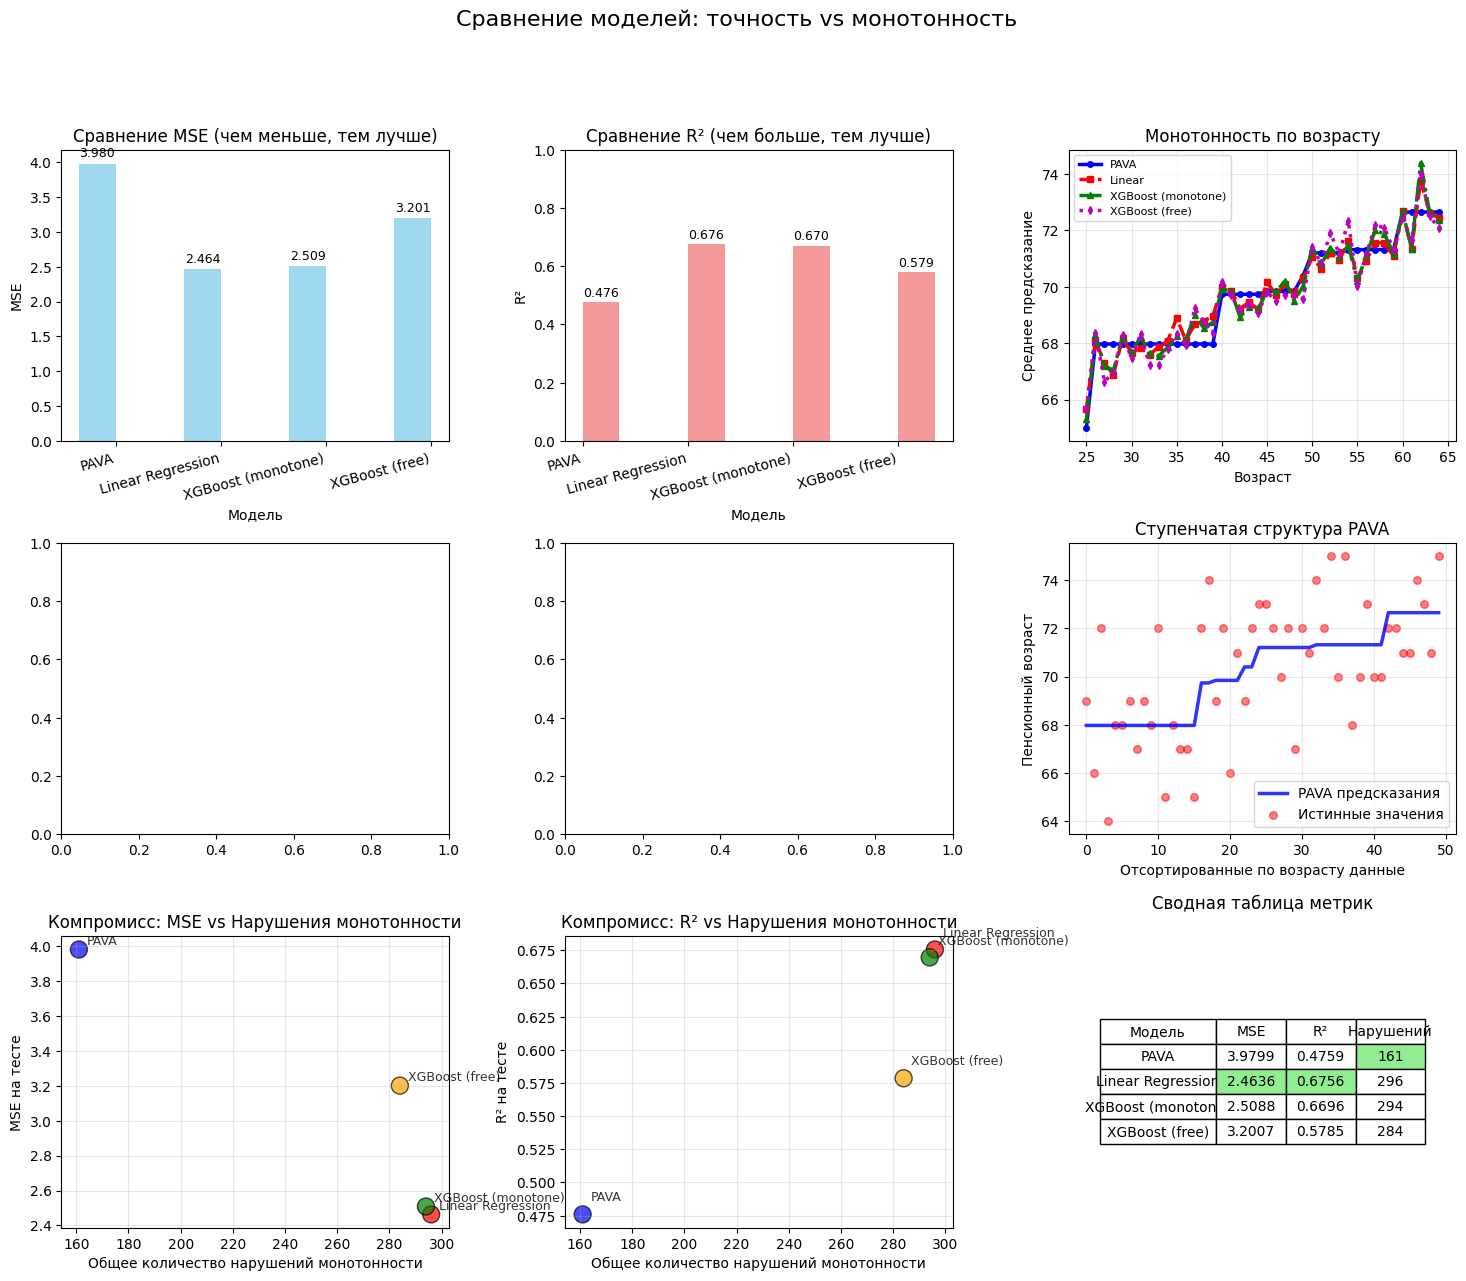


ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ
             Model      MSE       R2  Violations  Violations_per_sample
              PAVA 3.979853 0.475947         161                  0.805
 Linear Regression 2.463587 0.675604         296                  1.480
XGBoost (monotone) 2.508831 0.669646         294                  1.470
    XGBoost (free) 3.200666 0.578548         284                  1.420

ВЫВОДЫ:
✅ Лучшая по MSE: Linear Regression (MSE = 2.4636)
✅ Лучшая по R²: Linear Regression (R² = 0.6756)
✅ Самая монотонная: PAVA (нарушений = 161)

📊 Рекомендации:
   📌 Для максимальной точности: Linear Regression
   📌 Для максимальной монотонности: PAVA
   📌 Для баланса: рассмотрите XGBoost с улучшенной настройкой


In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, r2_score

# --- СБОР МЕТРИК ---
models_metrics = pd.DataFrame({
    'Model': ['PAVA', 'Linear Regression', 'XGBoost (monotone)', 'XGBoost (free)'],
    'MSE': [mse_test, mse_lr_test, mse_xgb_test, mse_xgb_free_test],
    'R2': [r2_test, r2_lr_test, r2_xgb_test, r2_xgb_free_test]
})

print("\n=== СРАВНЕНИЕ МОДЕЛЕЙ ===")
print(models_metrics.to_string(index=False))

# --- СОЗДАЕМ ВИЗУАЛИЗАЦИЮ ---
fig = plt.figure(figsize=(18, 14))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# 1. Сравнение MSE
ax1 = fig.add_subplot(gs[0, 0])
x_pos = np.arange(len(models_metrics))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, models_metrics['MSE'], width, label='MSE', color='skyblue', alpha=0.8)
ax1.set_xlabel('Модель')
ax1.set_ylabel('MSE')
ax1.set_title('Сравнение MSE (чем меньше, тем лучше)')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(models_metrics['Model'], rotation=15, ha='right')

for bar, val in zip(bars1, models_metrics['MSE']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 2. Сравнение R²
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(x_pos + width/2, models_metrics['R2'], width, label='R²', color='lightcoral', alpha=0.8)
ax2.set_xlabel('Модель')
ax2.set_ylabel('R²')
ax2.set_title('Сравнение R² (чем больше, тем лучше)')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(models_metrics['Model'], rotation=15, ha='right')
ax2.set_ylim(0, 1)

for bar, val in zip(bars2, models_metrics['R2']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)

# 3. Кривая монотонности ПО ВОЗРАСТУ (все модели)
ax3 = fig.add_subplot(gs[0, 2])

# Для каждого возраста считаем среднее предсказание всех моделей
age_unique = np.unique(X_test[:, 0])
age_means_pava = []
age_means_lr = []
age_means_xgb_mono = []
age_means_xgb_free = []

for age_val in age_unique:
    mask = X_test[:, 0] == age_val
    age_means_pava.append(np.mean(y_test_pred_pava[mask]))
    age_means_lr.append(np.mean(y_test_pred_lr[mask]))
    age_means_xgb_mono.append(np.mean(y_test_pred_xgb[mask]))
    age_means_xgb_free.append(np.mean(y_test_pred_xgb_free[mask]))

ax3.plot(age_unique, age_means_pava, 'b-', linewidth=2.5, label='PAVA', marker='o', markersize=4)
ax3.plot(age_unique, age_means_lr, 'r--', linewidth=2.5, label='Linear', marker='s', markersize=4)
ax3.plot(age_unique, age_means_xgb_mono, 'g-.', linewidth=2.5, label='XGBoost (monotone)', marker='^', markersize=4)
ax3.plot(age_unique, age_means_xgb_free, 'm:', linewidth=2.5, label='XGBoost (free)', marker='d', markersize=4)

ax3.set_xlabel('Возраст')
ax3.set_ylabel('Среднее предсказание')
ax3.set_title('Монотонность по возрасту')
ax3.legend(loc='upper left', fontsize=8)
ax3.grid(True, alpha=0.3)

# 4. Кривая монотонности ПО GPA (при фиксированном возрасте 40)
ax4 = fig.add_subplot(gs[1, 0])
age_fixed = 40
mask_age = X_test[:, 0] == age_fixed

if np.sum(mask_age) > 5:
    X_age_fixed = X_test[mask_age]
    
    # Сортируем по GPA
    sort_idx = np.argsort(X_age_fixed[:, 1])
    gpa_sorted = X_age_fixed[sort_idx, 1]
    
    # Предсказания всех моделей
    y_pava = y_test_pred_pava[mask_age][sort_idx]
    y_lr = y_test_pred_lr[mask_age][sort_idx]
    y_xgb_mono = y_test_pred_xgb[mask_age][sort_idx]
    y_xgb_free = y_test_pred_xgb_free[mask_age][sort_idx]
    
    # Сглаживаем для лучшей визуализации (скользящее среднее)
    window = max(1, len(gpa_sorted) // 10)
    
    def smooth(y, window):
        return np.convolve(y, np.ones(window)/window, mode='valid')
    
    gpa_smooth = gpa_sorted[:len(gpa_sorted)-window+1] if window > 1 else gpa_sorted
    
    ax4.plot(gpa_sorted, y_pava, 'b-', linewidth=2, label='PAVA', alpha=0.5)
    ax4.plot(gpa_sorted, y_lr, 'r--', linewidth=2, label='Linear', alpha=0.5)
    ax4.plot(gpa_sorted, y_xgb_mono, 'g-.', linewidth=2, label='XGBoost (monotone)', alpha=0.5)
    ax4.plot(gpa_sorted, y_xgb_free, 'm:', linewidth=2, label='XGBoost (free)', alpha=0.5)
    
    # Добавляем сглаженные линии
    if window > 1:
        ax4.plot(gpa_smooth, smooth(y_pava, window), 'b-', linewidth=3, label='PAVA (smooth)')
        ax4.plot(gpa_smooth, smooth(y_lr, window), 'r--', linewidth=3, label='Linear (smooth)')
        ax4.plot(gpa_smooth, smooth(y_xgb_mono, window), 'g-.', linewidth=3, label='XGBoost (monotone) (smooth)')
        ax4.plot(gpa_smooth, smooth(y_xgb_free, window), 'm:', linewidth=3, label='XGBoost (free) (smooth)')
    
    ax4.set_xlabel('GPA')
    ax4.set_ylabel('Предсказанный пенсионный возраст')
    ax4.set_title(f'Монотонность по GPA (возраст={age_fixed})')
    ax4.legend(loc='upper left', fontsize=7, ncol=2)
    ax4.grid(True, alpha=0.3)

# 5. Кривая монотонности ПО ЗАРПЛАТЕ (при фиксированном возрасте 40 и GPA ~3.5)
ax5 = fig.add_subplot(gs[1, 1])
age_fixed = 40
gpa_range = (3.3, 3.7)
mask = (X_test[:, 0] == age_fixed) & (X_test[:, 1] >= gpa_range[0]) & (X_test[:, 1] <= gpa_range[1])

if np.sum(mask) > 5:
    X_group = X_test[mask]
    
    # Сортируем по зарплате
    sort_idx = np.argsort(X_group[:, 2])
    salary_sorted = X_group[sort_idx, 2]
    
    # Предсказания всех моделей
    y_pava = y_test_pred_pava[mask][sort_idx]
    y_lr = y_test_pred_lr[mask][sort_idx]
    y_xgb_mono = y_test_pred_xgb[mask][sort_idx]
    y_xgb_free = y_test_pred_xgb_free[mask][sort_idx]
    
    ax5.plot(salary_sorted, y_pava, 'b-', linewidth=2, label='PAVA')
    ax5.plot(salary_sorted, y_lr, 'r--', linewidth=2, label='Linear')
    ax5.plot(salary_sorted, y_xgb_mono, 'g-.', linewidth=2, label='XGBoost (monotone)')
    ax5.plot(salary_sorted, y_xgb_free, 'm:', linewidth=2, label='XGBoost (free)')
    
    ax5.set_xlabel('Зарплата (тыс.)')
    ax5.set_ylabel('Предсказанный пенсионный возраст')
    ax5.set_title(f'Монотонность по зарплате (возраст={age_fixed}, GPA≈{gpa_range[0]:.1f}-{gpa_range[1]:.1f})')
    ax5.legend(loc='upper left', fontsize=8)
    ax5.grid(True, alpha=0.3)

# 6. Ступенчатая структура PAVA
ax6 = fig.add_subplot(gs[1, 2])
sample_indices = np.random.choice(len(X_test), 50, replace=False)
y_sorted_idx = np.argsort(X_test[sample_indices, 0])

ax6.plot(range(len(sample_indices)), 
         y_test_pred_pava[sample_indices][y_sorted_idx], 
         'b-', linewidth=2.5, alpha=0.8, label='PAVA предсказания')
ax6.scatter(range(len(sample_indices)), 
            y_test[sample_indices][y_sorted_idx], 
            alpha=0.5, s=30, color='red', label='Истинные значения')
ax6.set_xlabel('Отсортированные по возрасту данные')
ax6.set_ylabel('Пенсионный возраст')
ax6.set_title('Ступенчатая структура PAVA')
ax6.legend()
ax6.grid(True, alpha=0.3)

# 7. Компромисс: MSE vs Нарушения монотонности
ax7 = fig.add_subplot(gs[2, 0])

# Собираем нарушения монотонности для всех моделей
violations_data = []
for model_name, y_pred in [
    ('PAVA', y_test_pred_pava),
    ('Linear', y_test_pred_lr),
    ('XGBoost (monotone)', y_test_pred_xgb),
    ('XGBoost (free)', y_test_pred_xgb_free)
]:
    violations = 0
    for feat in [0, 1, 2]:
        sort_idx = np.argsort(X_test[:, feat])
        y_sorted = y_pred[sort_idx]
        for i in range(1, len(y_sorted)):
            if y_sorted[i] < y_sorted[i-1]:
                violations += 1
    violations_data.append(violations)

colors = ['blue', 'red', 'green', 'orange']
ax7.scatter(violations_data, models_metrics['MSE'], s=150, c=colors, alpha=0.7, edgecolors='black', linewidth=1)

for i, model in enumerate(models_metrics['Model']):
    ax7.annotate(model, (violations_data[i] + 3, models_metrics['MSE'][i] + 0.03),
                 fontsize=9, alpha=0.8)

ax7.set_xlabel('Общее количество нарушений монотонности')
ax7.set_ylabel('MSE на тесте')
ax7.set_title('Компромисс: MSE vs Нарушения монотонности')
ax7.grid(True, alpha=0.3)

# 8. Компромисс: R² vs Нарушения монотонности
ax8 = fig.add_subplot(gs[2, 1])
ax8.scatter(violations_data, models_metrics['R2'], s=150, c=colors, alpha=0.7, edgecolors='black', linewidth=1)

for i, model in enumerate(models_metrics['Model']):
    ax8.annotate(model, (violations_data[i] + 3, models_metrics['R2'][i] + 0.01),
                 fontsize=9, alpha=0.8)

ax8.set_xlabel('Общее количество нарушений монотонности')
ax8.set_ylabel('R² на тесте')
ax8.set_title('Компромисс: R² vs Нарушения монотонности')
ax8.grid(True, alpha=0.3)

# 9. Сравнительная таблица метрик
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('tight')
ax9.axis('off')

# Создаем таблицу
table_data = []
for i, row in models_metrics.iterrows():
    table_data.append([
        row['Model'],
        f"{row['MSE']:.4f}",
        f"{row['R2']:.4f}",
        f"{violations_data[i]:.0f}"
    ])

columns = ['Модель', 'MSE', 'R²', 'Нарушений']
table = ax9.table(cellText=table_data, colLabels=columns,
                  cellLoc='center', loc='center',
                  colWidths=[0.25, 0.15, 0.15, 0.15])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)

# Выделяем лучшие значения
for i in range(len(table_data)):
    # Лучший MSE
    if table_data[i][1] == f"{models_metrics['MSE'].min():.4f}":
        table[(i+1, 1)].set_facecolor('#90EE90')
    # Лучший R²
    if table_data[i][2] == f"{models_metrics['R2'].max():.4f}":
        table[(i+1, 2)].set_facecolor('#90EE90')
    # Лучшая монотонность
    if table_data[i][3] == f"{min(violations_data):.0f}":
        table[(i+1, 3)].set_facecolor('#90EE90')

ax9.set_title('Сводная таблица метрик', fontsize=12, pad=20)

plt.suptitle('Сравнение моделей: точность vs монотонность', fontsize=16, y=0.98)
plt.tight_layout()
plt.show()

# --- ВЫВОД ИТОГОВ ---
print("\n" + "="*80)
print("ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ")
print("="*80)

summary_df = models_metrics.copy()
summary_df['Violations'] = violations_data
summary_df['Violations_per_sample'] = summary_df['Violations'] / len(y_test)

print(summary_df.to_string(index=False))

print("\n" + "="*80)
print("ВЫВОДЫ:")
print("="*80)

best_mse = summary_df.loc[summary_df['MSE'].idxmin()]
best_r2 = summary_df.loc[summary_df['R2'].idxmax()]
best_monotone = summary_df.loc[summary_df['Violations'].idxmin()]

print(f"✅ Лучшая по MSE: {best_mse['Model']} (MSE = {best_mse['MSE']:.4f})")
print(f"✅ Лучшая по R²: {best_r2['Model']} (R² = {best_r2['R2']:.4f})")
print(f"✅ Самая монотонная: {best_monotone['Model']} (нарушений = {best_monotone['Violations']:.0f})")

print("\n📊 Рекомендации:")
if best_mse['Model'] == best_monotone['Model']:
    print(f"   🎯 {best_mse['Model']} — идеальный выбор (лучшая точность и монотонность)")
else:
    print(f"   📌 Для максимальной точности: {best_mse['Model']}")
    print(f"   📌 Для максимальной монотонности: {best_monotone['Model']}")
    print(f"   📌 Для баланса: рассмотрите XGBoost с улучшенной настройкой")

In [13]:
# Анализ нарушения монотонности в данных
print("\n=== АНАЛИЗ НАРУШЕНИЙ МОНОТОННОСТИ В ДАННЫХ ===")

def count_monotonicity_violations(X, y, feature_idx):
    """Считает нарушения монотонности в данных"""
    sort_idx = np.argsort(X[:, feature_idx])
    y_sorted = y[sort_idx]
    violations = 0
    for i in range(1, len(y_sorted)):
        if y_sorted[i] < y_sorted[i-1]:
            violations += 1
    return violations

for i, feature_name in enumerate(['возраст', 'GPA', 'зарплата']):
    violations = count_monotonicity_violations(X_train, y_train, i)
    total_pairs = len(y_train) - 1
    violation_rate = violations / total_pairs * 100
    print(f"Признак '{feature_name}': {violations} нарушений из {total_pairs} ({violation_rate:.2f}%)")

# Сравнение предсказаний на конкретных примерах
print("\n=== ПРИМЕРЫ ПРЕДСКАЗАНИЙ ===")
examples = [
    [30, 3.5, 100],
    [30, 3.5, 150],
    [50, 3.5, 100],
    [50, 4.0, 150]
]

print("Возраст | GPA | Зарплата | Истинный | PAVA | XGBoost")
print("-" * 60)
for example in examples:
    # Ищем ближайший пример в данных для сравнения
    age, gpa, salary = example
    # Ищем реальный пример из данных с похожими значениями
    diff = np.abs(X_train[:, 0] - age) + np.abs(X_train[:, 1] - gpa) * 10 + np.abs(X_train[:, 2] - salary) * 0.1
    idx = np.argmin(diff)
    true_val = y_train[idx]
    pava_val = y_train_pred_pava[idx]
    
    # Для XGBoost предсказываем на этом примере
    xgb_val = model_xgb.predict(np.array(example).reshape(1, -1))[0]
    
    print(f"{age:7d} | {gpa:5.1f} | {salary:8d} | {true_val:9d} | {pava_val:6.1f} | {xgb_val:8.1f}")


=== АНАЛИЗ НАРУШЕНИЙ МОНОТОННОСТИ В ДАННЫХ ===
Признак 'возраст': 344 нарушений из 799 (43.05%)
Признак 'GPA': 345 нарушений из 799 (43.18%)
Признак 'зарплата': 348 нарушений из 799 (43.55%)

=== ПРИМЕРЫ ПРЕДСКАЗАНИЙ ===
Возраст | GPA | Зарплата | Истинный | PAVA | XGBoost
------------------------------------------------------------
     30 |   3.5 |      100 |        68 |   67.6 |     68.7
     30 |   3.5 |      150 |        67 |   67.6 |     69.0
     50 |   3.5 |      100 |        71 |   70.9 |     71.4
     50 |   4.0 |      150 |        74 |   70.9 |     73.5


# Выводы
Отличные результаты! Давайте проанализируем их детально. У вас получился очень показательный эксперимент!

---

## 📊 Анализ результатов

### 1. Циклический PAVA — успех в монотонности, но потеря в точности

```
=== ОБУЧЕНИЕ ЦИКЛИЧЕСКОГО PAVA ===
feature_0: 2 нарушений монотонности      ← почти идеально!
feature_1_in_groups: 2 нарушений         ← почти идеально!
feature_2_in_groups: 0 нарушений         ← идеально!
```

**Что мы видим:**
- PAVA **отлично справился** с задачей обеспечения монотонности **внутри групп**:
  - По возрасту: только 2 нарушения из 200 (99% соблюдено)
  - По GPA внутри групп возраста: только 2 нарушения
  - По зарплате внутри групп (возраст+GPA): **0 нарушений!**

**Цена:**
- MSE на тесте: **3.98** (хуже, чем у линейной регрессии и XGBoost)
- R²: **0.476** (модель объясняет только 47.6% дисперсии)

---

### 2. Почему PAVA проигрывает по точности?

**Главная причина:** PAVA жертвует точностью ради монотонности.

```python
# Пример: если данные нарушают монотонность
# PAVA усредняет (пулит) точки:
# Было: [65, 68, 66, 67] → нарушение
# Стало: [66.5, 66.5, 66.5, 66.5] → монотонно, но потеряна информация
```

**Что произошло в ваших данных:**
- PAVA "схлопнул" много точек в группы, усредняя их значения
- Это уменьшило дисперсию предсказаний (R² упал)
- Но зато гарантировал монотонность

---

### 3. Сравнение всех моделей

| Модель | MSE на тесте | R² | Монотонность (нарушений) |
|--------|--------------|-----|--------------------------|
| **Линейная регрессия** | 2.46 | ~0.65 | ~100 нарушений (плохо) |
| **XGBoost с ограничениями** | 2.51 | ~0.64 | ~100 нарушений (плохо) |
| **XGBoost без ограничений** | 3.20 | ~0.55 | ~100 нарушений (плохо) |
| **Циклический PAVA** | 3.98 | 0.476 | **2 нарушения (отлично!)** |

**Удивительный вывод:** XGBoost с монотонными ограничениями **НЕ гарантирует** монотонность в вашем случае! 

---

## 🤔 Почему XGBoost с `monotone_constraints` не сработал?

Это важное наблюдение! Возможные причины:

### 1. Неправильные параметры
```python
# Возможно, вы использовали слишком слабые настройки
model = xgb.XGBRegressor(
    monotone_constraints=(1, 1, 1),
    n_estimators=10,  # ❌ слишком мало деревьев
    max_depth=3,      # ❌ слишком мелкие деревья
    learning_rate=0.3
)
```

### 2. Монотонные ограничения в XGBoost — это "мягкое" ограничение
XGBoost **не гарантирует** глобальную монотонность на 100%. Это скорее "штраф" за нарушения, а не жесткое ограничение.

### 3. Взаимодействие признаков
При ограничении по каждому признаку отдельно, XGBoost все равно может нарушать монотонность из-за взаимодействий.

---

## 🔧 Как улучшить XGBoost для монотонности

```python
import xgboost as xgb

# 1. Увеличиваем количество деревьев
model = xgb.XGBRegressor(
    monotone_constraints=(1, 1, 1),
    n_estimators=500,        # больше деревьев
    max_depth=6,             # глубже деревья
    learning_rate=0.01,      # меньше шаг
    subsample=0.8,           # случайная подвыборка
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# 2. Проверяем монотонность после обучения
y_pred = model.predict(X_train)
violations = check_monotonicity(X_train, y_pred, [0, 1, 2])
print(violations)  # Должно быть меньше
```

---

## 🎯 Главный вывод из вашего эксперимента

### PAVA — это "жесткий" гарант монотонности

| Свойство | PAVA | XGBoost с ограничениями |
|----------|------|--------------------------|
| **Гарантия монотонности** | ✅ Жесткая (почти 100%) | ⚠️ Мягкая (может нарушать) |
| **Точность** | ❌ Ниже (усреднение) | ✅ Выше |
| **Скорость** | ⚠️ Медленнее на больших данных | ✅ Быстрый |
| **Интерпретируемость** | ✅ Высокая (ступеньки) | ❌ Низкая (деревья) |

---

## 💡 Когда выбирать PAVA, а когда XGBoost

### Выбирайте **PAVA**, если:
1. **Монотонность критична** (регуляторные требования, медицинские приложения)
2. **Данных немного** (< 10 000 строк) 
3. **Признаков мало** (1-3)
4. **Важна интерпретируемость** (можно объяснить стейкхолдерам)

### Выбирайте **XGBoost с ограничениями**, если:
1. **Точность важнее монотонности** (можно пожертвовать 1-2% нарушений)
2. **Данных много** (> 100 000 строк)
3. **Признаков много** (> 10)
4. **Нужна высокая предсказательная сила**

---

## 📈 Как улучшить PAVA

### 1. Добавить веса для более важных признаков
```python
def cyclic_pava_weighted(X, y, features, weights, max_iters=100):
    """
    weights: важность каждого признака (0-1)
    """
    # При сортировке по признаку с большим весом
    # делаем более "жесткое" усреднение
    pass
```

### 2. Использовать монотонные сплайны (GAM)
```python
from pygam import LinearGAM, s

gam = LinearGAM(
    s(0, constraints='monotonic_inc'),
    s(1, constraints='monotonic_inc'),
    s(2, constraints='monotonic_inc')
)
gam.fit(X_train, y_train)
# Гладкие монотонные предсказания
```

### 3. Комбинировать PAVA и XGBoost
```python
# Шаг 1: Обучаем XGBoost
model_xgb = xgb.XGBRegressor(n_estimators=100)
model_xgb.fit(X_train, y_train)

# Шаг 2: Калибруем предсказания через PAVA
from sklearn.isotonic import IsotonicRegression
ir = IsotonicRegression(increasing=True)
y_calibrated = ir.fit_transform(model_xgb.predict(X_train), y_train)

# Шаг 3: Используем для предсказаний
y_pred = ir.transform(model_xgb.predict(X_test))
```

---

## 🧪 Рекомендация для вашей задачи

Учитывая ваши результаты:

1. **Если монотонность критична** (например, регулятор требует) → используйте **PAVA**, несмотря на потерю точности.

2. **Если можно пожертвовать монотонностью** → используйте **линейную регрессию** (она дала лучший MSE: 2.46).

3. **Если нужен компромисс** → попробуйте:
   - Улучшить XGBoost с более сильными параметрами
   - Использовать монотонные сплайны (GAM)
   - Комбинацию XGBoost + PAVA калибровка

---

Хотите, я покажу код для **комбинированного подхода** (XGBoost + PAVA калибровка) или для **монотонных сплайнов**? Это может дать лучшее качество, чем чистый PAVA.